# Phase 1: Rolling Window Baseline Analysis

This notebook establishes baseline performance metrics and data quality assessments for merchant cost prediction tasks.

## Current Phase: Data Analysis & Baseline Establishment

- **Weekly merchant profiles**: Aggregate transaction data into cost_percent and feature distributions
- **Rolling window framework**: 4-week onboarding context → 12-week forecast horizon (year-crossover support)
- **Baseline model**: Mean of context window = forecast for evaluation period
- **Data quality metrics**: Dropout rates (missing data) by window and merchant
- **Output**: Baseline performance benchmarks to beat with prediction models

## Future Phase: Model Testing & Transfer Learning

In Phase 2, k-NN transfer learning will be introduced to:
- Handle new merchants with sparse onboarding data
- Transfer knowledge from similar established merchants
- Serve as a feature engineering/data augmentation step for prediction models

In [91]:
# Core
import numpy as np
import pandas as pd

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
# ============================================================================
# GLOBAL TESTING / SCENARIO CONFIGURATION
# ============================================================================

# 1. Target Definition
MCC_TARGET = 5411

# 2. Dataset Representation (Subsampling)
# Control the size of the dataset to reduce processing time during development.
DATASET_REPRESENTATION = 'fraction'   # 'full', 'fraction', or 'count'
REPRESENTATION_PARAM = 0.10           # If 'fraction': 0.0-1.0; if 'count': integer>0

# 3. Rolling Window Configuration
WINDOW_CONTEXT_LEN = 4                # Number of weeks in onboarding context window
WINDOW_EVAL_LEN = 12                  # Number of weeks in evaluation/forecast window (12 eval + buffer)
WINDOW_TOTAL_LEN = WINDOW_CONTEXT_LEN + WINDOW_EVAL_LEN
WINDOW_START_WEEKS = list(range(1, 53))  # 1..52, rolling positions (can cross year boundary)
EVAL_ALL_START_WEEKS = True  # If True, evaluate all possible start weeks; if False, pick a random start week from the merchant

# Current single-window analysis focus (default start week)
CURRENT_START_WEEK = 1

# Derived Weeks (do not edit manually unless needed)
CONTEXT_WEEKS = list(range(CURRENT_START_WEEK, CURRENT_START_WEEK + WINDOW_CONTEXT_LEN))
EVAL_WEEKS_SCENARIO = list(range(CURRENT_START_WEEK + WINDOW_CONTEXT_LEN, CURRENT_START_WEEK + WINDOW_TOTAL_LEN))
FORECAST_WEEKS_SCENARIO = list(range(CURRENT_START_WEEK, CURRENT_START_WEEK + WINDOW_TOTAL_LEN))

# 4. Data Quality Thresholds
MIN_CTX_NON_NULL = 4                  # Min non-null context points required to run a scenario
MAX_EVAL_MISSING = 4                  # Max missing eval weeks allowed for evaluation inclusion
MIN_EVAL_NON_NULL = len(EVAL_WEEKS_SCENARIO) - MAX_EVAL_MISSING # Derived min non-null eval points

# 5. k-NN / Feature Configuration
COST_TYPE_IDS = list(range(1, 62))
ID_COLS = ['split_year', 'week_of_year', 'merchant_id']
K_NEIGHBORS = 5
EPS = 1e-9
TRAJECTORY_WEEKS = CONTEXT_WEEKS      # Use default context weeks as the signature weeks for matching

print('✓ Global testing configuration loaded')
print(f'  Target MCC: {MCC_TARGET}')
print(f'  Dataset settings: {DATASET_REPRESENTATION} ({REPRESENTATION_PARAM})')
print(f'  Context weeks: {CONTEXT_WEEKS}')
print(f'  Eval weeks:    {EVAL_WEEKS_SCENARIO}')

✓ Global testing configuration loaded
  Target MCC: 5411
  Dataset settings: fraction (0.1)
  Context weeks: [1, 2, 3, 4]
  Eval weeks:    [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [93]:
def build_weekly_merchant_features(df, split_year):
    """
    Aggregate transaction-level data into weekly merchant profiles.
    Computes cost_percent, transaction counts, and cost-type distributions per week.
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['date'].dt.year == split_year].copy()

    year_start = pd.Timestamp(f'{split_year}-01-01')
    day_offset = (df['date'] - year_start).dt.days
    df['week_of_year'] = np.clip((day_offset // 7) + 1, 1, 52).astype(int)

    df['cost_type_ID'] = pd.to_numeric(df['cost_type_ID'], errors='coerce').astype('Int64')
    df['txn_cost_percent'] = np.where(df['amount'] != 0, df['proc_cost'] / df['amount'], np.nan)

    weekly_summary = (
        df.groupby(['merchant_id', 'week_of_year'], as_index=False)
        .agg(
            total_proc_cost=('proc_cost', 'sum'),
            total_amount=('amount', 'sum'),
            total_transactions=('transaction_id', 'count'),
            cost_percent_stdev=('txn_cost_percent', 'std'),
        )
    )
    
    # Calculate overall cost percent
    weekly_summary['cost_percent'] = np.where(
        weekly_summary['total_amount'] != 0,
        weekly_summary['total_proc_cost'] / weekly_summary['total_amount'],
        np.nan
    )
    
    # Build cost-type features (cost per transaction by cost_type_ID)
    cost_by_type = (
        df.groupby(['merchant_id', 'week_of_year', 'cost_type_ID'], as_index=False)
        .agg(proc_cost=('proc_cost', 'sum'))
    )
    
    # Pivot to get cost_type_ID as columns
    cost_pivot = cost_by_type.pivot_table(
        index=['merchant_id', 'week_of_year'],
        columns='cost_type_ID',
        values='proc_cost',
        fill_value=0
    )
    
    # Rename columns to match expected format
    cost_pivot.columns = [f'cost_type_{cid}' for cid in cost_pivot.columns]
    cost_pivot = cost_pivot.reset_index()
    
    # Merge features back with weekly_summary
    weekly_features = weekly_summary.merge(cost_pivot, on=['merchant_id', 'week_of_year'], how='left')
    
    # Fill missing cost_type columns with 0
    for col in weekly_features.columns:
        if col.startswith('cost_type_') and weekly_features[col].isna().any():
            weekly_features[col] = weekly_features[col].fillna(0)
    
    # Add split_year for reference
    weekly_features['split_year'] = split_year
    
    # Reorder columns with ID columns first
    # ID_COLS is now defined in Global Config
    id_cols_local = ['split_year', 'week_of_year', 'merchant_id'] 
    other_cols = [c for c in weekly_features.columns if c not in id_cols_local]
    weekly_features = weekly_features[id_cols_local + other_cols]
    
    return weekly_features

In [94]:
# Load transaction data and prepare weekly panel
# MCC_TARGET is now defined in Global Config

raw_df = pd.read_csv('processed_transactions_4mcc.csv')
print(f'Raw data shape: {raw_df.shape}')
print(f'MCCs present: {sorted(raw_df["mcc"].unique())}')

# Filter to target MCC
all_df = raw_df[raw_df['mcc'] == MCC_TARGET].copy()
print(f'After filtering to MCC {MCC_TARGET}: {len(all_df):,} rows')

# Clean: remove NaN cost_type_ID and error rows
all_df = all_df[all_df['cost_type_ID'] != 'NaN']
all_df = all_df.dropna(subset=['cost_type_ID'])
# Skip errors filter if column doesn't exist
if 'errors' in all_df.columns:
    all_df = all_df[all_df['errors'].isna()].copy()

print(f'After cleaning: {len(all_df):,} rows')

# Extract year from date for grouping
all_df['date'] = pd.to_datetime(all_df['date'], errors='coerce')
all_df['year'] = all_df['date'].dt.year

# Group by year
years_present = sorted(all_df['year'].dropna().unique().astype(int).tolist())
print(f'Years in data: {years_present}')

# Build weekly features for each year separately
weekly_dfs = []
for year in years_present:
    year_df = all_df[all_df['year'] == year].copy()
    weekly_year = build_weekly_merchant_features(year_df, year)
    weekly_dfs.append(weekly_year)
    print(f'  {year}: {len(year_df):,} rows → {len(weekly_year)} weekly records')

# Combine all years
all_weekly_df = pd.concat(weekly_dfs, ignore_index=True).sort_values(
    ['split_year', 'merchant_id', 'week_of_year']
).reset_index(drop=True)

feature_cols = [col for col in all_weekly_df.columns if col not in ID_COLS]

print(f'\n✓ Data loaded and weekly features computed')
print(f'  Total weekly records: {len(all_weekly_df):,}')
print(f'  Years represented: {sorted(all_weekly_df["split_year"].unique().astype(int).tolist())}')
print(f'  Total merchants: {all_weekly_df["merchant_id"].nunique():,}')
print(f'  Feature columns: {len(feature_cols)}')

Raw data shape: (3880158, 11)
MCCs present: [np.int64(4121), np.int64(5411), np.int64(5499), np.int64(5812)]
After filtering to MCC 5411: 1,446,227 rows
After cleaning: 1,446,227 rows
Years in data: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  2010: 133,559 rows → 33019 weekly records
  2011: 139,510 rows → 34052 weekly records
  2012: 144,174 rows → 35075 weekly records
  2013: 147,445 rows → 35450 weekly records
  2014: 148,723 rows → 35974 weekly records
  2015: 151,075 rows → 36168 weekly records
  2016: 151,300 rows → 36154 weekly records
  2017: 152,248 rows → 36499 weekly records
  2018: 152,090 rows → 36405 weekly records
  2019: 126,103 rows → 30528 weekly records

✓ Data loaded and weekly features computed
  Total weekly records: 349,324
  Years represented: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  Total merchants: 7,996
  Feature columns: 21


In [95]:
# ============================================================================
# CONFIGURABLE DATASET REPRESENTATION
# ============================================================================
# Uses Global Config settings: DATASET_REPRESENTATION, REPRESENTATION_PARAM

# Apply subsampling
np.random.seed(42)  # For reproducibility
unique_merchants = all_weekly_df['merchant_id'].unique()

if DATASET_REPRESENTATION == 'full':
    working_weekly_df = all_weekly_df.copy()
    representation_info = f'Full dataset ({len(working_weekly_df):,} records, {len(unique_merchants):,} merchants)'
    
elif DATASET_REPRESENTATION == 'fraction':
    # Sample a fraction of merchants
    fraction = float(REPRESENTATION_PARAM)
    merchant_sample = np.random.choice(unique_merchants, size=int(len(unique_merchants) * fraction), replace=False)
    working_weekly_df = all_weekly_df[all_weekly_df['merchant_id'].isin(merchant_sample)].copy()
    representation_info = f'Fraction {fraction:.1%} ({len(working_weekly_df):,} records, {len(merchant_sample):,} merchants)'
    
elif DATASET_REPRESENTATION == 'count':
    # Sample a fixed number of merchants
    count = int(REPRESENTATION_PARAM)
    merchant_sample = np.random.choice(unique_merchants, size=min(count, len(unique_merchants)), replace=False)
    working_weekly_df = all_weekly_df[all_weekly_df['merchant_id'].isin(merchant_sample)].copy()
    representation_info = f'Fixed count {count} ({len(working_weekly_df):,} records, {len(merchant_sample):,} merchants)'
    
else:
    raise ValueError(f"Invalid DATASET_REPRESENTATION: {DATASET_REPRESENTATION}")

print(f'Dataset representation: {representation_info}')
print(f'  Years: {sorted(working_weekly_df["split_year"].unique().astype(int).tolist())}')
print(f'  Weeks per year: 1-52')
print(f'✓ Ready for analysis with {len(working_weekly_df):,} weekly records')

Dataset representation: Fraction 10.0% (38,642 records, 799 merchants)
  Years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  Weeks per year: 1-52
✓ Ready for analysis with 38,642 weekly records


## Configurable Dataset Representation

The notebook now supports **configurable data subsampling** to reduce processing time during development and testing.

### Configuration Options

Edit the **DATASET_REPRESENTATION** setting in the cell above to choose one of three modes:

1. **'full'** - Use all data (original behavior, slowest)
   ```python
   DATASET_REPRESENTATION = 'full'
   REPRESENTATION_PARAM = None  # Ignored when mode is 'full'
   ```
   Result: All merchants across all years

2. **'fraction'** - Sample a percentage of merchants (recommended for development)
   ```python
   DATASET_REPRESENTATION = 'fraction'
   REPRESENTATION_PARAM = 0.1  # 0.0-1.0 range (e.g., 0.1 = 10%)
   ```
   Result: Random 10% of merchants → ~40K records if full dataset is ~400K

3. **'count'** - Sample a fixed number of merchants (useful for consistent testing)
   ```python
   DATASET_REPRESENTATION = 'count'
   REPRESENTATION_PARAM = 500  # Exact merchant count
   ```
   Result: Exactly 500 merchants randomly selected

### Impact on Processing Time

- **10% representation** (~40K records, ~1K merchants): **~10-20× faster**
- **1% representation** (~4K records, ~100 merchants): **~100× faster** (quick prototyping)
- **Full (100%)**: Original speed, most data coverage

### How It Works

1. After loading the full dataset (`all_weekly_df`), a subsampled copy is created called `working_weekly_df`
2. All subsequent cells automatically use `working_weekly_df` instead of the full dataset
3. Merchants are sampled with `random.seed(42)` for **reproducible selection**
4. All years and weeks are preserved for the selected merchants

### Tips

- **For development/testing**: Use `'fraction': 0.1` (10%) - good balance of speed vs. data coverage
- **For quick prototyping**: Use `'fraction': 0.05` (5%) or `'count': 100`
- **For final analysis**: Use `'full'` to include all merchants
- Change the seed in the cell to get different merchant samples: `np.random.seed(YOUR_SEED)`

## [PHASE 2] k-NN Composite Merchant Construction

**This section is reserved for Phase 2 (model testing with transfer learning). In Phase 1, this infrastructure is not used.**

When activated in Phase 2, the k-NN methodology will implement:

1. **Standardize pool features**: Apply StandardScaler to normalize the historical merchant pool
2. **Build trajectories**: Extract onboarding-week signatures for all merchants
3. **Compute weighted distances**: Multi-scale Euclidean distance with feature-specific weights
4. **Select k-neighbors**: Find k=5 nearest merchants by signature similarity
5. **Weight neighbors**: Inverse-distance weighting for knowledge transfer
6. **Build synthetic history**: Aggregate neighbors' historical data for new merchants with sparse data

In [96]:
def build_weekly_trajectory_matrix(weekly_df, feature_cols, trajectory_weeks):
    """
    Build one feature vector per merchant by concatenating week-specific features.
    Missing week-feature values are filled with 0.0 for stable distance computation.
    """
    rows = []

    for mid, grp in weekly_df.groupby('merchant_id'):
        rec = {'merchant_id': int(mid)}
        for wk in trajectory_weeks:
            wk_slice = grp[grp['week_of_year'] == wk]
            for col in feature_cols:
                key = f'w{wk}_{col}'
                if not wk_slice.empty and pd.notna(wk_slice[col].iloc[0]):
                    rec[key] = float(wk_slice[col].iloc[0])
                else:
                    rec[key] = 0.0
        rows.append(rec)

    return pd.DataFrame(rows)


def build_composite_for_query_merchant(
    query_merchant_id,
    pool_weekly_df,
    query_weekly_df,
    feature_cols,
    id_cols=ID_COLS,
    trajectory_weeks=TRAJECTORY_WEEKS,
    k_neighbors=K_NEIGHBORS,
    eps=EPS,
):
    """
    Build a single composite merchant from k-NN neighbors for a query merchant.
    """

    # Extract pool history (exclude query merchant)
    pool_history = pool_weekly_df[
        (pool_weekly_df['merchant_id'] != query_merchant_id)
    ].copy()
    if pool_history.empty:
        raise ValueError('Pool is empty (all merchants or query merchant excluded)')

    # Standardize features across pool
    scaler = StandardScaler()
    scaler.fit(pool_history[feature_cols].fillna(0.0))

    # Get query merchant's trajectory data
    query_jan = query_weekly_df[
        (query_weekly_df['merchant_id'] == query_merchant_id)
        & (query_weekly_df['week_of_year'].isin(trajectory_weeks))
    ].copy()
    if query_jan.empty:
        raise ValueError(f'Query merchant {query_merchant_id} has no data in trajectory weeks')

    # Standardize pool and query using the same scaler
    pool_history_z = pool_history[id_cols].copy()
    pool_history_z[feature_cols] = scaler.transform(pool_history[feature_cols].fillna(0.0))

    query_jan_z = query_jan[id_cols].copy()
    query_jan_z[feature_cols] = scaler.transform(query_jan[feature_cols].fillna(0.0))

    # Build trajectory matrices (feature snapshots for matching weeks)
    pool_traj = build_weekly_trajectory_matrix(pool_history_z, feature_cols, trajectory_weeks)
    query_traj = build_weekly_trajectory_matrix(query_jan_z, feature_cols, trajectory_weeks)
    if pool_traj.empty or query_traj.empty:
        raise ValueError('Trajectory construction failed for pool or query')

    X_pool = pool_traj.drop(columns=['merchant_id']).values
    X_query = query_traj.drop(columns=['merchant_id']).values
    pool_ids = pool_traj['merchant_id'].values
    traj_feature_names = pool_traj.drop(columns=['merchant_id']).columns.tolist()

    # Define feature weights (higher weights = more important for distance)
    feature_weight_map = {name: 1.0 for name in traj_feature_names}
    for fname in traj_feature_names:
        if fname.endswith('_cost_percent') and not fname.endswith('_stdev'):
            feature_weight_map[fname] = 3.0
        elif fname.endswith('_total_transactions'):
            feature_weight_map[fname] = 2.5
        elif fname.endswith('_cost_percent_stdev'):
            feature_weight_map[fname] = 2.0

    weight_vector = np.array([feature_weight_map[name] for name in traj_feature_names])

    # Compute weighted Euclidean distance from query to each pool merchant
    weighted_dist = np.sqrt((((X_pool - X_query[0]) ** 2) * weight_vector).sum(axis=1))

    # Select k nearest neighbors
    k_local = min(k_neighbors, len(weighted_dist))
    top_idx = np.argsort(weighted_dist)[:k_local]

    # Create neighbor info DataFrame
    neighbor_info = pd.DataFrame({
        'neighbor_merchant_id': pool_ids[top_idx].astype(int),
        'distance': weighted_dist[top_idx].astype(float),
    })
    neighbor_info['raw_weight'] = 1.0 / (neighbor_info['distance'] + eps)
    neighbor_info['normalized_weight'] = neighbor_info['raw_weight'] / neighbor_info['raw_weight'].sum()

    # Get historical data for selected neighbors
    neighbor_history = pool_weekly_df[
        (pool_weekly_df['merchant_id'].isin(neighbor_info['neighbor_merchant_id']))
        & (pool_weekly_df['merchant_id'] != query_merchant_id)
    ].copy()
    if neighbor_history.empty:
        raise ValueError('Neighbor history is empty')

    # Merge weights into neighbor history
    weight_map = neighbor_info.set_index('neighbor_merchant_id')['normalized_weight'].to_dict()
    neighbor_history['weight'] = neighbor_history['merchant_id'].map(weight_map)

    # Build a single synthetic merchant by weighted aggregation across neighbors per week.
    weighted_history = neighbor_history.copy()
    for col in feature_cols:
        weighted_history[col] = weighted_history[col] * weighted_history['weight']

    composite = (
        weighted_history
        .groupby(['split_year', 'week_of_year'], as_index=False)[feature_cols]
        .sum()
        .sort_values(['split_year', 'week_of_year'])
        .reset_index(drop=True)
    )
    composite['merchant_id'] = int(query_merchant_id)
    composite = composite[['split_year', 'week_of_year', 'merchant_id'] + feature_cols]

    return {
        'composite_history': composite,
        'neighbor_info': neighbor_info,
        'k_local': k_local,
        'query_jan': query_jan,
        'scaler': scaler,
    }

## [PHASE 2] Example: Build k-NN Composite for a Sample Merchant

**This section demonstrates k-NN transfer learning for Phase 2. It is not used in Phase 1.**

To activate in Phase 2: Select neighbors from historical merchant pool based on onboarding signature, then aggregate their weighted history to create synthetic training data for new merchants.

In [97]:
# # Select a sample merchant from most recent year
# all_years = sorted(working_weekly_df['split_year'].unique().astype(int).tolist())
# query_year = all_years[-1]  # Most recent year
# query_df = working_weekly_df[working_weekly_df['split_year'] == query_year].copy()

# print(f'Query year: {query_year}')
# years_str = str(all_years[:-1]) if len(all_years) > 1 else f"(plus up to week 4 of {query_year})"
# print(f'Available years in pool: {years_str}')

# # Choose a sample merchant with context-week coverage so k-NN scenario is valid
# jan_coverage = (
#     query_df[query_df['week_of_year'].isin(TRAJECTORY_WEEKS)]
#     .groupby('merchant_id')['cost_percent']
#     .apply(lambda x: x.notna().sum())
# )
# eligible_sample_merchants = sorted(jan_coverage[jan_coverage >= 1].index.tolist())
# if not eligible_sample_merchants:
#     raise ValueError('No merchants in query year have context-week coverage')

# sample_merchant_id = eligible_sample_merchants[len(eligible_sample_merchants) // 2]

# print(f'\nQuery merchant: {sample_merchant_id}')
# print(f'Query data available in Jan: {int(jan_coverage.loc[sample_merchant_id])} weeks')

# # Build scenario using dynamic pool (all merchants except query, up to context weeks in query_year, plus all prior years)
# scenario = prepare_onboarding_scenario(
#     query_merchant_id=sample_merchant_id,
#     all_weekly_df_full=working_weekly_df,
#     query_year=query_year,
#     feature_cols_list=feature_cols,
# )

# if scenario is None:
#     raise ValueError('Scenario preparation failed for the selected sample merchant')

# # Display results
# k_selected = scenario['neighbor_info'].shape[0]
# print(f'\n✓ Scenario prepared successfully')
# print(f'  Neighbors selected: {k_selected}')
# print(f'  Pool size: {scenario["pool_size"]}')

# neighbor_info = scenario['neighbor_info'].copy()
# print('\nNeighbors preview:')
# neighbor_display = neighbor_info[['neighbor_merchant_id', 'distance', 'normalized_weight']].copy()
# neighbor_display.columns = ['neighbor_id', 'weighted_distance', 'weight']
# neighbor_display['weight_pct'] = (neighbor_display['weight'] * 100).round(1)
# print(neighbor_display.head(10).to_string(index=False))

# print(f'\nComposite history shape: {scenario["composite_history"].shape}')
# print(f'Composite query-year shape: {scenario["composite_query_year"].shape}')
# print(f'Non-null rows in composite query year: {scenario["composite_query_year"]["cost_percent"].notna().sum()}')

# # Show sample of composite values
# print('\nSample of composite query-year data (first 5 weeks):')
# display(scenario['composite_query_year'].head(5)[ID_COLS + ['cost_percent', 'total_transactions']].round(4))

## k-NN Batch Processing: Scale to Multiple Merchants

Build composites for a sample of merchants and analyze success rates, coverage, and neighbor statistics.

In [98]:
# # Build composites for a sample of merchants
# sample_size = 50
# batch_merchants = sorted(query_df['merchant_id'].unique())[:sample_size]
# batch_results = []
# batch_failures = []

# print(f'Building k-NN composites for {len(batch_merchants)} merchants...\n')

# for i, mid in enumerate(batch_merchants, start=1):
#     try:
#         scenario = prepare_onboarding_scenario(
#             query_merchant_id=mid,
#             all_weekly_df_full=working_weekly_df,
#             query_year=query_year,
#             feature_cols_list=feature_cols,
#         )
        
#         k_selected = scenario['neighbor_info'].shape[0]
#         batch_results.append({
#             'merchant_id': mid,
#             'neighbors_selected': k_selected,
#             'pool_size': scenario['pool_size'],
#             'success': True,
#         })
        
#     except Exception as e:
#         batch_failures.append({
#             'merchant_id': mid,
#             'error': str(e)
#         })
    
#     if (i % 10 == 0) or (i == len(batch_merchants)):
#         print(f'  Processed {i}/{len(batch_merchants)} merchants')

# batch_df = pd.DataFrame(batch_results)
# print(f'\n✓ Batch k-NN complete')
# print(f'  Query year: {query_year}')
# print(f'  Pool includes: All years before {query_year}, plus {query_year} weeks 1-4')
# print(f'  Total merchants: {len(batch_merchants)}')
# print(f'  Successful: {len(batch_df)}')
# print(f'  Failed: {len(batch_failures)}')

## Model Testing Framework

Standardized framework for evaluating models on an onboarding scenario:
- **Context window**: 4 weeks (Jan weeks 1-4)
- **Prediction horizon**: 12 weeks (weeks 5-16)
- **Input**: Query merchant's k-NN composite history + Jan transaction signature
- **Baseline**: Mean of context window (weeks 1-4) as constant forecast
- **Metrics**: MAE, MAPE

In [99]:
# Evaluation metrics
def compute_mae(y_true, y_pred):
    """Mean Absolute Error"""
    return float(np.mean(np.abs(y_true - y_pred)))

def compute_mape(y_true, y_pred, epsilon=1e-12):
    """
    Mean Absolute Percentage Error.
    Handles zero values by requiring y_true to be reasonably large.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    # Only compute MAPE where y_true is not too small
    mask = np.abs(y_true) > epsilon
    if not mask.any():
        return np.nan
    
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    return float(np.mean(ape) * 100)  # Return as percentage

def evaluate_predictions(y_actual, y_pred, y_baseline=None):
    """
    Compute MAE and MAPE for predictions.
    Optionally compute improvement over baseline.
    """
    result = {
        'mae': compute_mae(y_actual, y_pred),
        'mape': compute_mape(y_actual, y_pred),
    }
    
    if y_baseline is not None:
        baseline_mae = compute_mae(y_actual, y_baseline)
        baseline_mape = compute_mape(y_actual, y_baseline)
        result['baseline_mae'] = baseline_mae
        result['baseline_mape'] = baseline_mape
        result['mae_improvement'] = baseline_mae - result['mae']  # Positive = better
        result['mae_improvement_pct'] = (result['mae_improvement'] / np.clip(baseline_mae, 1e-12, None)) * 100
        result['mape_improvement'] = baseline_mape - result['mape']
        result['mape_improvement_pct'] = (result['mape_improvement'] / np.clip(baseline_mape, 1e-12, None)) * 100
    
    return result

# Rolling window configuration & Constants are now in Global Config
print('✓ Metrics and constants defined')
print(f'  Rolling window configuration:')
print(f'    Context length: {WINDOW_CONTEXT_LEN} weeks')
print(f'    Eval length: {WINDOW_EVAL_LEN} weeks')
print(f'    Total window: {WINDOW_TOTAL_LEN} weeks')
print(f'    Possible start weeks: {len(WINDOW_START_WEEKS)} (weeks 1-52)')
print(f'  Current analysis window (start_week={CURRENT_START_WEEK}):')
print(f'    Context weeks: {CONTEXT_WEEKS}')
print(f'    Evaluation weeks: {EVAL_WEEKS_SCENARIO}')

✓ Metrics and constants defined
  Rolling window configuration:
    Context length: 4 weeks
    Eval length: 12 weeks
    Total window: 16 weeks
    Possible start weeks: 52 (weeks 1-52)
  Current analysis window (start_week=1):
    Context weeks: [1, 2, 3, 4]
    Evaluation weeks: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [100]:
# MIN_CTX_NON_NULL is now in Global Config

def prepare_onboarding_scenario(
    query_merchant_id,
    all_weekly_df_full,
    query_year,
    feature_cols_list,
    context_weeks=CONTEXT_WEEKS,
    eval_weeks=EVAL_WEEKS_SCENARIO,
    forecost_weeks=FORECAST_WEEKS_SCENARIO,
):
    """
    Prepare data for testing by building a k-NN composite for the query merchant.

    Pool includes all non-query merchants from historical years and onboarding context weeks.
    """
    # Query merchant data for onboarding year
    query_data = all_weekly_df_full[
        (all_weekly_df_full['merchant_id'] == query_merchant_id) &
        (all_weekly_df_full['split_year'] == query_year)
    ].copy()

    if query_data.empty:
        return None

    # Require at least two context-week observation to run onboarding scenario
    has_context = query_data[query_data['week_of_year'].isin(context_weeks)]['cost_percent'].notna().count() >= MIN_CTX_NON_NULL
    if not has_context:
        return None

    # Build pool: all non-query merchants from years < query_year, plus query_year context weeks
    max_context_week = max(context_weeks)
    pool_mask = (
        (all_weekly_df_full['merchant_id'] != query_merchant_id) &
        (
            (all_weekly_df_full['split_year'] < query_year) |
            ((all_weekly_df_full['split_year'] == query_year) & (all_weekly_df_full['week_of_year'] <= max_context_week))
        )
    )
    pool_data_full = all_weekly_df_full[pool_mask].copy()
    if pool_data_full.empty:
        return None

    # Build k-NN composite history
    composite_dict = build_composite_for_query_merchant(
        query_merchant_id=query_merchant_id,
        pool_weekly_df=pool_data_full,
        query_weekly_df=query_data,
        feature_cols=feature_cols_list,
        id_cols=ID_COLS,
        trajectory_weeks=context_weeks,
        k_neighbors=K_NEIGHBORS,
        eps=EPS,
    )

    composite_history = composite_dict['composite_history']

    # Align composite to query_year for convenient downstream use.
    composite_query_year = composite_history[composite_history['split_year'] == query_year].copy()
    if composite_query_year.empty:
        weekly_profile = (
            composite_history.groupby('week_of_year', as_index=False)[feature_cols_list]
            .mean()
        )
        composite_query_year = weekly_profile.copy()
        composite_query_year['split_year'] = query_year
        composite_query_year['merchant_id'] = query_merchant_id
        composite_query_year = composite_query_year[ID_COLS + feature_cols_list]

    return {
        'query_merchant_id': query_merchant_id,
        'query_year': query_year,
        'query_data': query_data.sort_values('week_of_year').reset_index(drop=True),
        'pool_data': pool_data_full,
        'neighbor_info': composite_dict['neighbor_info'],
        'pool_size': len(pool_data_full),
        'composite_history': composite_history,
        'composite_query_year': composite_query_year.sort_values('week_of_year').reset_index(drop=True),
    }

In [101]:
# ============================================================================
# BASELINE FORECAST FUNCTION (Phase 1 Only)
# ============================================================================
# In Phase 1, we evaluate the baseline model directly against merchant actuals.
# In Phase 2, a model registry will be added for testing additional models.

def baseline_constant_mean(context_values, num_weeks=None):
    """
    PHASE 1 BASELINE: Predict the mean of the context window for all evaluation weeks.
    
    This is the metric all Phase 2 models will need to beat.
    
    Args:
        context_values: numpy array of context-window cost_percent values
        num_weeks: Number of weeks to predict (optional, defaults to len(EVAL_WEEKS_SCENARIO))
    
    Returns:
        numpy array of predictions for the evaluation period
    """
    if num_weeks is None:
        num_weeks = len(EVAL_WEEKS_SCENARIO)
    mean_val = float(np.mean(context_values))
    return np.full(num_weeks, mean_val)

print('✓ Baseline forecast function defined')
print('  Phase 1: Evaluate baseline against merchant actuals')
print('  Phase 2: Register and test additional models')

✓ Baseline forecast function defined
  Phase 1: Evaluate baseline against merchant actuals
  Phase 2: Register and test additional models


In [102]:
# ============================================================================
# MODEL FRAMEWORK: REGISTRY & ROLLING EVALUATION
# ============================================================================

MODEL_REGISTRY = {}

def register_model(name, model_class_or_func, description=""):
    """Register a model for testing."""
    MODEL_REGISTRY[name] = {
        'model': model_class_or_func,
        'description': description,
    }
    print(f'✓ Registered: {name}')

def get_registered_models():
    """Get list of all registered model names."""
    return sorted(MODEL_REGISTRY.keys())

def get_valid_test_scenarios(
    merchant_ids,
    all_weekly_df_full,
    query_year,
):
    """
    PRE-FILTERING: Identify one valid rolling window per merchant satisfying all data quality checks.
    
    Returns:
        DataFrame of valid scenarios: ['merchant_id', 'start_week', 'query_year']
    """
    import random
    valid_scenarios = []
    
    print(f"Scanning {len(merchant_ids)} merchants for valid rolling windows...")
    
    processed_count = 0
    for mid in merchant_ids:
        processed_count += 1
        
        # Optimize: Fetch data for merchant once
        merchant_full_data = all_weekly_df_full[
            (all_weekly_df_full['merchant_id'] == mid) & 
            (all_weekly_df_full['split_year'].isin([query_year, query_year + 1]))
        ].copy()
        
        if merchant_full_data.empty:
            continue
            
        merchant_full_data_indexed = merchant_full_data.set_index(['split_year', 'week_of_year']).sort_index()

        # Randomize start weeks to find *any* valid window
        possible_start_weeks = list(WINDOW_START_WEEKS)
        random.shuffle(possible_start_weeks)
        
        for start_week in possible_start_weeks:
            try:
                # ----------------------------------------------------------------
                # 1. Define Temporal Window
                # ----------------------------------------------------------------
                
                # Context Window
                context_weeks_config = []
                for w_idx in range(WINDOW_CONTEXT_LEN):
                    abs_week = start_week + w_idx
                    y_off = (abs_week - 1) // 52
                    eff_year = query_year + y_off
                    eff_week = (abs_week - 1) % 52 + 1
                    context_weeks_config.append((eff_year, eff_week))
                
                # Eval Window
                eval_weeks_config = []
                for w_idx in range(WINDOW_CONTEXT_LEN, WINDOW_TOTAL_LEN):
                    abs_week = start_week + w_idx
                    y_off = (abs_week - 1) // 52
                    eff_year = query_year + y_off
                    eff_week = (abs_week - 1) % 52 + 1
                    eval_weeks_config.append((eff_year, eff_week))
                
                # ----------------------------------------------------------------
                # 2. Extract Data & Check Quality
                # ----------------------------------------------------------------
                
                # Check 1: Context Data Existence
                try:
                    context_data_rows = merchant_full_data_indexed.reindex(context_weeks_config)
                    context_vals = context_data_rows['cost_percent'].values.astype(float)
                except KeyError:
                    continue
                
                # Check 2: Eval Data Existence
                try:
                    eval_data_rows = merchant_full_data_indexed.reindex(eval_weeks_config)
                    eval_vals = eval_data_rows['cost_percent'].values.astype(float)
                except KeyError:
                    continue
                
                # Check 3: Context Coverage
                valid_ctx_mask = ~np.isnan(context_vals)
                if valid_ctx_mask.sum() < MIN_CTX_NON_NULL:
                    continue 
                    
                # Check 4: Eval Coverage
                valid_eval_mask = ~np.isnan(eval_vals)
                if (len(eval_vals) - valid_eval_mask.sum()) > MAX_EVAL_MISSING:
                    continue 
                if valid_eval_mask.sum() == 0:
                     continue

                # If all checks pass, record this scenario and move to next merchant
                valid_scenarios.append({
                    'merchant_id': mid,
                    'start_week': start_week,
                    'query_year': query_year
                })
                break
            
            except Exception:
                continue

    scenarios_df = pd.DataFrame(valid_scenarios)
    print(f"✓ Found {len(scenarios_df)} valid scenarios out of {len(merchant_ids)} merchants")
    return scenarios_df


def evaluate_model_on_merchants(
    test_scenarios_df,
    all_weekly_df_full,
    model_name,
    model_obj,
    pool_weekly_df=None,
    verbose=True,
    return_predictions=False,
):
    """
    Evaluate a model on PRE-FILTERED valid scenarios.
    
    Args:
        test_scenarios_df: DataFrame with ['merchant_id', 'start_week', 'query_year']
    """
    results = []
    failures = []
    predictions = {}
    
    if test_scenarios_df.empty:
        print("Warning: No test scenarios provided.")
        return pd.DataFrame(), pd.DataFrame(), {} if return_predictions else (pd.DataFrame(), pd.DataFrame())

    for i, row in enumerate(test_scenarios_df.to_dict('records'), start=1):
        mid = row['merchant_id']
        start_week = row['start_week']
        query_year = row['query_year']
        
        try:
            # Re-fetch specific merchant data (could optimize by passing in, but this is safe)
            merchant_full_data = all_weekly_df_full[
                (all_weekly_df_full['merchant_id'] == mid) & 
                (all_weekly_df_full['split_year'].isin([query_year, query_year + 1]))
            ].copy()
            
            merchant_full_data_indexed = merchant_full_data.set_index(['split_year', 'week_of_year']).sort_index()

            # ----------------------------------------------------------------
            # 1. Re-Define Window (We know it's valid, but need indices)
            # ----------------------------------------------------------------
            context_weeks_config = []
            context_week_nums = []
            for w_idx in range(WINDOW_CONTEXT_LEN):
                abs_week = start_week + w_idx
                y_off = (abs_week - 1) // 52
                eff_year = query_year + y_off
                eff_week = (abs_week - 1) % 52 + 1
                context_weeks_config.append((eff_year, eff_week))
                context_week_nums.append(eff_week)
            
            eval_weeks_config = []
            eval_week_nums = []
            for w_idx in range(WINDOW_CONTEXT_LEN, WINDOW_TOTAL_LEN):
                abs_week = start_week + w_idx
                y_off = (abs_week - 1) // 52
                eff_year = query_year + y_off
                eff_week = (abs_week - 1) % 52 + 1
                eval_weeks_config.append((eff_year, eff_week))
                eval_week_nums.append(eff_week)

            # ----------------------------------------------------------------
            # 2. Extract Data
            # ----------------------------------------------------------------
            context_data_rows = merchant_full_data_indexed.reindex(context_weeks_config)
            eval_data_rows = merchant_full_data_indexed.reindex(eval_weeks_config)
            
            window_data = pd.concat([context_data_rows, eval_data_rows]).reset_index()
            
            # Recalculate masks just for metrics
            context_vals = context_data_rows['cost_percent'].values.astype(float)
            eval_vals = eval_data_rows['cost_percent'].values.astype(float)
            valid_ctx_mask = ~np.isnan(context_vals)
            valid_eval_mask = ~np.isnan(eval_vals)

            # ----------------------------------------------------------------
            # 3. Prepare Pool (Dynamic)
            # ----------------------------------------------------------------
            dynamic_pool = None
            if 'composite' in model_name.lower():
                cutoff_year, cutoff_week = max(context_weeks_config)
                pool_mask = (
                    (all_weekly_df_full['merchant_id'] != mid) & 
                    (
                        (all_weekly_df_full['split_year'] < cutoff_year) | 
                        (
                            (all_weekly_df_full['split_year'] == cutoff_year) & 
                            (all_weekly_df_full['week_of_year'] <= cutoff_week)
                        )
                    )
                )
                dynamic_pool = all_weekly_df_full[pool_mask].copy()

            # ----------------------------------------------------------------
            # 4. Run Prediction
            # ----------------------------------------------------------------
            if 'composite' in model_name.lower():
                model_pred_full = model_obj.predict(
                    query_merchant_id=mid,
                    query_data=window_data,
                    context_weeks=context_week_nums,
                    eval_weeks=eval_week_nums,
                    all_weekly_df=all_weekly_df_full,
                    feature_cols=feature_cols,
                    pool_weekly_df=dynamic_pool,
                )
            else:
                model_pred_full = model_obj.predict(
                    query_merchant_id=mid,
                    query_data=window_data,
                    context_weeks=context_week_nums,
                    eval_weeks=eval_week_nums,
                    all_weekly_df=all_weekly_df_full,
                    feature_cols=feature_cols,
                )
            
            if return_predictions:
                predictions[(mid, start_week)] = model_pred_full

            # ----------------------------------------------------------------
            # 5. Metrics
            # ----------------------------------------------------------------
            eval_actual_real = eval_vals[valid_eval_mask]
            model_pred_actual = model_pred_full[valid_eval_mask]

            mae = compute_mae(eval_actual_real, model_pred_actual)
            mape = compute_mape(eval_actual_real, model_pred_actual)

            results.append({
                'merchant_id': mid,
                'start_week': start_week,
                'query_year': query_year,
                'model_name': model_name,
                'context_real': int(valid_ctx_mask.sum()),
                'eval_real': int(valid_eval_mask.sum()),
                'mae': mae,
                'mape': mape,
            })

        except Exception as e:
            failures.append({
                'merchant_id': mid,
                'model_name': model_name,
                'error': str(e),
            })
        
        if verbose and (i % 50 == 0 or i == len(test_scenarios_df)):
            print(f'  Evaluated {i}/{len(test_scenarios_df)} scenarios...')

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df[[
            'merchant_id', 'start_week', 'query_year', 'model_name',
            'context_real', 'eval_real', 'mae', 'mape',
        ]]

    failures_df = pd.DataFrame(failures) if failures else pd.DataFrame()
    return results_df, failures_df, predictions if return_predictions else (results_df, failures_df)


print('✓ Model registry and evaluation framework defined')


# ============================================================================
# BASELINE MODEL
# ============================================================================

class BaselineConstantMean:
    """
    Baseline model: predict mean of context window for all eval weeks.
    """
    
    def __init__(self):
        pass
    
    def predict(self, query_merchant_id, query_data, context_weeks, eval_weeks,
                all_weekly_df, feature_cols):
        """Predict using mean of context weeks."""
        context_values = []
        for wk in context_weeks:
            q = query_data.loc[query_data['week_of_year'] == wk, 'cost_percent']
            if len(q) > 0 and pd.notna(q.iloc[0]):
                context_values.append(float(q.iloc[0]))
        
        if len(context_values) == 0:
            return np.full(len(eval_weeks), 0.5)  # Default fallback
        
        mean_val = np.mean(context_values)
        return np.full(len(eval_weeks), mean_val)

baseline_model = BaselineConstantMean()

register_model(
    name='baseline_constant_mean',
    model_class_or_func=baseline_model,
    description='Baseline: constant mean of context window'
)

def evaluate_baseline_on_merchants(
    merchant_ids,
    all_weekly_df_full,
    query_year,
    verbose=True,
):
    """
    Wrapper for legacy compatibility.
    NOW GENERATES SCENARIOS internally if called directly.
    """
    scenarios = get_valid_test_scenarios(merchant_ids, all_weekly_df_full, query_year)
    return evaluate_model_on_merchants(
        test_scenarios_df=scenarios,
        all_weekly_df_full=all_weekly_df_full,
        model_name='baseline_constant_mean',
        model_obj=baseline_model,
        pool_weekly_df=None,
        verbose=verbose
    )

print('✓ Baseline model defined and registered')

✓ Model registry and evaluation framework defined
✓ Registered: baseline_constant_mean
✓ Baseline model defined and registered


In [103]:
# # ============================================================================
# # WEEK-WISE LINEAR REGRESSION MODEL
# # ============================================================================
# # Strategy:
# # - Train a separate linear regression for each week
# # - Week N model: learn from pool merchants' week N features to predict week N+1 cost
# # - For target merchant, use observed week N to predict week N+1
# # - For subsequent weeks, use predicted week values as input
# # ============================================================================

# from sklearn.linear_model import LinearRegression

# class WeekwiseLinearRegression:
#     """
#     Week-wise linear regression models with mean-anchored residual learning.
    
#     Strategy: Predict deviations from the context window mean, not absolute values.
#     This preserves the stability of the baseline mean while allowing feature-informed adjustments.
    
#     Each week has its own regression:
#       week_N_features → (week_(N+1)_cost - mean(context_weeks))
#     Applies to target merchant by: prediction = context_mean + residual_adjustment
#     """
    
#     def __init__(self, feature_cols, id_cols=ID_COLS):
#         self.feature_cols = feature_cols
#         self.id_cols = id_cols
#         self.models = {}  # week -> LinearRegression model
#         self.merchant_context_means = {}  # merchant_id -> context_mean (for target merchant)
#         self.is_trained = False
    
#     def train(self, pool_weekly_df):
#         """
#         Train week-wise models predicting residuals from merchant context means.
        
#         Updated to support ROLLING CONTEXT:
#         For each week N model (predicting N+1), the "context mean" is calculated from the
#         WINDOW_CONTEXT_LEN weeks immediately preceding the prediction target.
        
#         Week 52 predicts week 1 of next year.
#         """
#         self.models = {}
        
#         for source_week in range(1, 53):
#             target_week = source_week + 1 if source_week < 52 else 1
            
#             # Get source week data (features for training input)
#             source_features = [f for f in self.feature_cols if f != 'cost_percent']
#             source_data = pool_weekly_df[
#                 pool_weekly_df['week_of_year'] == source_week
#             ][['merchant_id'] + source_features].copy()
            
#             # Get target week data (for computing cost_percent)
#             target_data = pool_weekly_df[
#                 pool_weekly_df['week_of_year'] == target_week
#             ][['merchant_id', 'cost_percent']].copy()
            
#             if source_data.empty or target_data.empty:
#                 continue
            
#             # Define dynamic rolling context weeks relative to source_week
#             # (Last WINDOW_CONTEXT_LEN weeks ending with source_week)
#             # e.g. if source=10, len=4 -> [7, 8, 9, 10]
#             dynamic_context_weeks = []
#             for k in range(WINDOW_CONTEXT_LEN):
#                 w = source_week - k
#                 if w < 1: w += 52
#                 dynamic_context_weeks.append(w)
            
#             # Compute context means for each merchant based on this specific window
#             context_data = pool_weekly_df[
#                 pool_weekly_df['week_of_year'].isin(dynamic_context_weeks)
#             ][['merchant_id', 'cost_percent']].copy()
            
#             context_means = context_data.groupby('merchant_id')['cost_percent'].mean()
            
#             # Merge: source features + target cost + context mean (as baseline)
#             merged = source_data.merge(target_data, on='merchant_id', how='inner')
#             merged = merged.merge(context_means.rename('context_mean'), left_on='merchant_id', right_index=True, how='inner')
            
#             if len(merged) < 2:
#                 continue
            
#             # Verify columns exist
#             if 'cost_percent' not in merged.columns or 'context_mean' not in merged.columns:
#                 raise ValueError(f'Week {source_week}: Missing columns. Available: {merged.columns.tolist()}')
            
#             X = merged[source_features].fillna(0).values
#             # Target: residual from context mean (not absolute value)
#             y = (merged['cost_percent'] - merged['context_mean']).fillna(0).values
            
#             # Train regression on residuals
#             model = LinearRegression()
#             model.fit(X, y)
#             self.models[source_week] = model
        
#         self.is_trained = True
#         print(f'✓ Trained week-wise residual LR models for {len(self.models)} weeks (rolling context-mean anchored)')
    
#     def predict(self, query_merchant_id, query_data, context_weeks, eval_weeks, 
#                 all_weekly_df, feature_cols):
#         """
#         Predict eval weeks for target merchant using mean-anchored residual learning.
        
#         Process:
#         1. Compute context mean from merchant's context weeks
#         2. For each eval week, predict residual from features
#         3. Return: context_mean + predicted_residual
#         """
#         if not self.is_trained:
#             raise ValueError('Model must be trained before prediction')
        
#         # Compute context mean for this merchant from the provided context window
#         context_actuals = query_data.loc[query_data['week_of_year'].isin(context_weeks), 'cost_percent']
#         context_mean = float(context_actuals[context_actuals.notna()].mean()) if context_actuals.notna().any() else 0.5
        
#         # Use same feature set as training (exclude cost_percent)
#         pred_features = [f for f in self.feature_cols if f != 'cost_percent']
        
#         predictions = []
#         current_values = {}  # Track predicted/actual values by week for next iteration
        
#         # Initialize with context week values
#         for wk in context_weeks:
#             q = query_data.loc[query_data['week_of_year'] == wk, pred_features]
#             if not q.empty:
#                 current_values[wk] = q.iloc[0].fillna(0).values
        
#         # Predict each eval week
#         for eval_week in eval_weeks:
#             # Determine source week for prediction
#             source_week = eval_week - 1 if eval_week > 1 else 52
            
#             if source_week not in self.models:
#                 # Model doesn't exist, fall back to context mean
#                 predictions.append(context_mean)
#                 continue
            
#             # Get features: prefer actual data, fall back to zeros
#             if source_week in current_values:
#                 features = current_values[source_week]
#             else:
#                 # Try to get from query data
#                 q = query_data.loc[query_data['week_of_year'] == source_week, pred_features]
#                 if not q.empty:
#                     features = q.iloc[0].fillna(0).values
#                 else:
#                     # Use zeros if no data available
#                     features = np.zeros(len(pred_features))
            
#             # Predict residual using trained model
#             residual = self.models[source_week].predict(features.reshape(1, -1))[0]
            
#             # Final prediction: context_mean + residual adjustment
#             pred = context_mean + residual
#             pred = np.clip(pred, 0, 1)  # Cost percent should be in [0, 1]
#             predictions.append(pred)
            
#             # Store prediction for next week's input
#             current_values[eval_week] = features  # Update with eval week features if available
        
#         return np.array(predictions)


# # # ============================================================================
# # # REGULARIZED RESIDUAL REGRESSION MODEL (Ridge)
# # # ============================================================================

# from sklearn.linear_model import Ridge

# class WeekwiseRidgeRegression:
#     """
#     Week-wise regularized (Ridge) regression with mean-anchored residual learning.
    
#     Extends WeekwiseLinearRegression with L2 regularization to prevent overfitting
#     on residual predictions. Uses Ridge regression instead of ordinary least squares.
    
#     Strategy: Predict deviations from context mean using regularized models.
#     Each week has its own Ridge model:
#       week_N_features → (week_(N+1)_cost - mean(context_weeks))
#     Applies to target merchant by: prediction = context_mean + regularized_residual
#     """
    
#     def __init__(self, feature_cols, alpha=0.1, id_cols=ID_COLS):
#         """
#         Args:
#             feature_cols: List of feature column names
#             alpha: Regularization strength (L2 penalty coefficient). Higher = more regularization.
#                    Typical range: 0.01 to 1.0
#             id_cols: Identifier columns
#         """
#         self.feature_cols = feature_cols
#         self.alpha = alpha
#         self.id_cols = id_cols
#         self.models = {}  # week -> Ridge model
#         self.is_trained = False
    
#     def train(self, pool_weekly_df):
#         """
#         Train week-wise Ridge models predicting residuals from merchant context means.
#         Regularization helps prevent overfitting to pool data noise.
#         """
#         self.models = {}
        
#         for source_week in range(1, 53):
#             target_week = source_week + 1 if source_week < 52 else 1
            
#             # Get source week data (features for training input)
#             source_features = [f for f in self.feature_cols if f != 'cost_percent']
#             source_data = pool_weekly_df[
#                 pool_weekly_df['week_of_year'] == source_week
#             ][['merchant_id'] + source_features].copy()
            
#             # Get target week data
#             target_data = pool_weekly_df[
#                 pool_weekly_df['week_of_year'] == target_week
#             ][['merchant_id', 'cost_percent']].copy()
            
#             if source_data.empty or target_data.empty:
#                 continue
            
#             # Define dynamic rolling context weeks relative to source_week
#             # (Last WINDOW_CONTEXT_LEN weeks ending with source_week)
#             dynamic_context_weeks = []
#             for k in range(WINDOW_CONTEXT_LEN):
#                 w = source_week - k
#                 if w < 1: w += 52
#                 dynamic_context_weeks.append(w)
            
#             # Compute context means for each merchant based on this specific window
#             context_data = pool_weekly_df[
#                 pool_weekly_df['week_of_year'].isin(dynamic_context_weeks)
#             ][['merchant_id', 'cost_percent']].copy()
            
#             context_means = context_data.groupby('merchant_id')['cost_percent'].mean()
            
#             # Merge: source features + target cost + context mean
#             merged = source_data.merge(target_data, on='merchant_id', how='inner')
#             merged = merged.merge(context_means.rename('context_mean'), left_on='merchant_id', right_index=True, how='inner')
            
#             if len(merged) < 2:
#                 continue
            
#             if 'cost_percent' not in merged.columns or 'context_mean' not in merged.columns:
#                 raise ValueError(f'Week {source_week}: Missing columns. Available: {merged.columns.tolist()}')
            
#             X = merged[source_features].fillna(0).values
#             # Target: residual from context mean
#             y = (merged['cost_percent'] - merged['context_mean']).fillna(0).values
            
#             # Train Ridge regression (L2 regularized)
#             model = Ridge(alpha=self.alpha)
#             model.fit(X, y)
#             self.models[source_week] = model
        
#         self.is_trained = True
#         print(f'✓ Trained week-wise Ridge models for {len(self.models)} weeks (alpha={self.alpha}, regularized residual learning)')
    
#     def predict(self, query_merchant_id, query_data, context_weeks, eval_weeks, 
#                 all_weekly_df, feature_cols):
#         """
#         Predict eval weeks using regularized residual learning.
#         """
#         if not self.is_trained:
#             raise ValueError('Model must be trained before prediction')
        
#         # Compute context mean for this merchant
#         context_actuals = query_data.loc[query_data['week_of_year'].isin(context_weeks), 'cost_percent']
#         context_mean = float(context_actuals[context_actuals.notna()].mean()) if context_actuals.notna().any() else 0.5
        
#         pred_features = [f for f in self.feature_cols if f != 'cost_percent']
        
#         predictions = []
#         current_values = {}
        
#         # Initialize with context week values
#         for wk in context_weeks:
#             q = query_data.loc[query_data['week_of_year'] == wk, pred_features]
#             if not q.empty:
#                 current_values[wk] = q.iloc[0].fillna(0).values
        
#         # Predict each eval week
#         for eval_week in eval_weeks:
#             source_week = eval_week - 1 if eval_week > 1 else 52
            
#             if source_week not in self.models:
#                 # Fall back to context mean if model doesn't exist
#                 predictions.append(context_mean)
#                 continue
            
#             # Get features
#             if source_week in current_values:
#                 features = current_values[source_week]
#             else:
#                 q = query_data.loc[query_data['week_of_year'] == source_week, pred_features]
#                 if not q.empty:
#                     features = q.iloc[0].fillna(0).values
#                 else:
#                     features = np.zeros(len(pred_features))
            
#             # Predict regularized residual
#             residual = self.models[source_week].predict(features.reshape(1, -1))[0]
            
#             # Final prediction: context_mean + regularized residual
#             pred = context_mean + residual
#             pred = np.clip(pred, 0, 1)
#             predictions.append(pred)
            
#             current_values[eval_week] = features
        
#         return np.array(predictions)


# # # ============================================================================
# # # k-NN COMPOSITE WRAPPER MODELS
# # # ============================================================================
# # # These models use the existing build_composite_for_query_merchant() function
# # # to create k-NN composites, then train existing weekwise models on them

# class CompositeWeekwiseLinearRegression:
#     """
#     Wrapper that builds k-NN composite for each merchant, then trains/predicts with WeekwiseLinearRegression.
#     Leverages existing composite building logic from notebook.
    
#     Refactored to support Dynamic Rolling Pool:
#     - No longer stores pool in __init__
#     - Receives `pool_weekly_df` in `predict()` method
#     """
    
#     def __init__(self, feature_cols):
#         self.feature_cols = feature_cols
#         # pool_weekly_df REMOVED from init to support dynamic pooling
#         self.is_trained = True # Technically trained on the fly per merchant
    
#     def predict(self, query_merchant_id, query_data, context_weeks, eval_weeks,
#                 all_weekly_df, feature_cols, pool_weekly_df):
#         """
#         For each query merchant:
#         1. Build k-NN composite using build_composite_for_query_merchant()
#            (Using the dynamically provided pool_weekly_df)
#         2. Train WeekwiseLinearRegression on that composite
#         3. Use trained model to make predictions
#         """
#         if pool_weekly_df is None:
#             raise ValueError("pool_weekly_df required for composite building")
        
#         # Build composite for this merchant
#         try:
#             scenario = build_composite_for_query_merchant(
#                 query_merchant_id=query_merchant_id,
#                 pool_weekly_df=pool_weekly_df,
#                 query_weekly_df=query_data,
#                 feature_cols=feature_cols,
#                 trajectory_weeks=context_weeks, 
#                 k_neighbors=K_NEIGHBORS,
#                 eps=EPS,
#             )
            
#             # Extract composite history
#             composite_history = scenario['composite_history']
            
#             # Train model on composite
#             composite_model = WeekwiseLinearRegression(feature_cols=feature_cols)
#             composite_model.train(composite_history)
            
#             # Make predictions
#             predictions = composite_model.predict(
#                 query_merchant_id=query_merchant_id,
#                 query_data=query_data,
#                 context_weeks=context_weeks,
#                 eval_weeks=eval_weeks,
#                 all_weekly_df=all_weekly_df,
#                 feature_cols=feature_cols,
#             )
            
#             return predictions
#         except Exception as e:
#             raise ValueError(f"Error in CompositeWeekwiseLinearRegression for merchant {query_merchant_id}: {e}") from e


# class CompositeWeekwiseRidgeRegression:
#     """
#     Wrapper that builds k-NN composite for each merchant, then trains/predicts with WeekwiseRidgeRegression.
#     Leverages existing composite building logic from notebook.

#     Refactored to support Dynamic Rolling Pool:
#     - No longer stores pool in __init__
#     - Receives `pool_weekly_df` in `predict()` method
#     """
    
#     def __init__(self, feature_cols, alpha=1.0):
#         self.feature_cols = feature_cols
#         # pool_weekly_df REMOVED from init to support dynamic pooling
#         self.alpha = alpha
#         self.is_trained = True # Technically trained on the fly
    
#     def predict(self, query_merchant_id, query_data, context_weeks, eval_weeks,
#                 all_weekly_df, feature_cols, pool_weekly_df=None):
#         """
#         For each query merchant:
#         1. Build k-NN composite using build_composite_for_query_merchant()
#            (Using the dynamically provided pool_weekly_df)
#         2. Train WeekwiseRidgeRegression on that composite
#         3. Use trained model to make predictions
#         """
#         if pool_weekly_df is None:
#             raise ValueError("pool_weekly_df required for composite building")
        
#         # Build composite for this merchant
#         try:
#             scenario = build_composite_for_query_merchant(
#                 query_merchant_id=query_merchant_id,
#                 pool_weekly_df=pool_weekly_df,
#                 query_weekly_df=query_data,
#                 feature_cols=feature_cols,
#                 trajectory_weeks=context_weeks, 
#                 k_neighbors=K_NEIGHBORS,
#                 eps=EPS,
#             )
            
#             # Extract composite history
#             composite_history = scenario['composite_history']
            
#             # Train model on composite
#             composite_model = WeekwiseRidgeRegression(feature_cols=feature_cols, alpha=self.alpha)
#             composite_model.train(composite_history)
            
#             # Make predictions
#             predictions = composite_model.predict(
#                 query_merchant_id=query_merchant_id,
#                 query_data=query_data,
#                 context_weeks=context_weeks, 
#                 eval_weeks=eval_weeks,
#                 all_weekly_df=all_weekly_df,
#                 feature_cols=feature_cols,
#             )
            
#             return predictions
#         except Exception as e:
#             raise ValueError(f"Error in CompositeWeekwiseRidgeRegression for merchant {query_merchant_id}: {e}") from e

####################################################################
# NEW MODEL: WEEKLY DECAYED AVERAGE
####################################################################
class WeeklyDecayedAverage:
    """
    Predicts eval weeks using a decayed average of context weeks.
    
    For each eval week, computes a weighted average of the context weeks' cost_percent,
    where weights decay exponentially based on the distance from the eval week.
    
    This model captures the intuition that more recent context weeks are more relevant
    for predicting near-term eval weeks, while still leveraging the full context window.
    """
    
    def __init__(self, decay_rate=0.5):
        """
        Args:
            decay_rate: Exponential decay rate (0 < decay_rate < 1). Higher = faster decay.
                        For example, 0.5 means each week further back is half as influential.
        """
        if not (0 < decay_rate < 1):
            raise ValueError("decay_rate must be between 0 and 1")
        self.decay_rate = decay_rate
    
    def predict(self, query_merchant_id, query_data, context_weeks, eval_weeks,
                all_weekly_df, feature_cols):
        """
        Predict eval weeks using decayed average of context weeks.
        
        For each eval week:
        - Compute weights for context weeks based on distance to eval week
        - Calculate weighted average of context cost_percent values
        - Return array of predictions for eval weeks
        """
        predictions = []
        
        for eval_week in eval_weeks:
            # Compute weights for context weeks based on distance to eval week
            weights = []
            values = []
            for ctx_week in context_weeks:
                distance = abs(eval_week - ctx_week)
                weight = self.decay_rate ** distance
                q = query_data.loc[query_data['week_of_year'] == ctx_week, 'cost_percent']
                if len(q) > 0 and pd.notna(q.iloc[0]):
                    weights.append(weight)
                    values.append(float(q.iloc[0]))
            
            if len(weights) == 0:
                # No valid context data, fall back to default
                predictions.append(0.5)
            else:
                # Compute weighted average
                weighted_avg = np.dot(weights, values) / np.sum(weights)
                predictions.append(weighted_avg)
        
        return np.array(predictions)

## Model Training & Evaluation

Train registered models on historical pool data and evaluate against held-out test merchants in the most recent year.

In [104]:
# # ============================================================================
# # DEBUGGING: Check model training status
# # ============================================================================

# print("Model training status check:")
# print("="*80)
# for model_name in get_registered_models():
#     model_obj = MODEL_REGISTRY[model_name]['model']
#     if hasattr(model_obj, 'is_trained'):
#         print(f'{model_name:30s}: is_trained = {model_obj.is_trained}')
#         if hasattr(model_obj, 'models'):
#             print(f'{" "*30}  Number of week models: {len(model_obj.models)}')
#     else:
#         print(f'{model_name:30s}: is_trained attribute not found')


In [105]:
# # ============================================================================
# # MANUAL TRAINING TEST
# # ============================================================================

# print("Testing WeekwiseLinearRegression.train() manually...")
# print("="*80)

# try:
#     # Try training on a small sample first
#     pool_sample = working_weekly_df.head(1000)  # Small sample for testing
#     print(f"Pool sample size: {len(pool_sample)} records")
#     print(f"Pool sample columns: {pool_sample.columns.tolist()}")
#     print(f"Feature columns: {feature_cols}")
#     print()
    
#     # Create a fresh model for testing
#     test_model = WeekwiseLinearRegression(feature_cols=feature_cols)
    
#     print("Calling train() on model...")
#     test_model.train(pool_sample)
    
#     print(f"✓ Training completed!")
#     print(f"  is_trained: {test_model.is_trained}")
#     print(f"  Number of models trained: {len(test_model.models)}")
    
# except Exception as e:
#     print(f"✗ Training failed with error:")
#     print(f"  Type: {type(e).__name__}")
#     print(f"  Message: {e}")
#     import traceback
#     print("\nFull traceback:")
#     traceback.print_exc()


In [106]:
import random

# ============================================================================
# TRAIN MODELS ON POOL DATA, EVALUATE ON TEST MERCHANTS
# ============================================================================

# Prepare test set from most recent year
all_years = sorted(working_weekly_df['split_year'].unique().astype(int).tolist())
if len(all_years) > 1:
    test_year = all_years[-1]
    train_years = all_years[:-1]
else:
    # Fallback if only 1 year exists (split by merchant instead of time? Or just warn)
    # For this notebook context, assume we have multiple years or just use same year for testing k-NN (risk of overfitting but functional)
    test_year = all_years[0]
    train_years = [] 
    print("Warning: Only 1 year of data. Training pool will be empty/invalid for strict time-split.")

# Pool: STRICTLY prior years to avoid data leakage in rolling windows
# We cannot include "early weeks" of test_year in pool because they are evaluation targets 
# for windows starting in late previous year or early current year.
if train_years:
    pool_data = working_weekly_df[working_weekly_df['split_year'].isin(train_years)].copy()
else:
    # If single year, maybe split by merchant ID? 
    # For now, let's assume we have history. If not, k-NN won't work well without a pool.
    pool_data = pd.DataFrame(columns=working_weekly_df.columns) # Empty

# Test Data: The target year for rolling evaluation
test_df = working_weekly_df[working_weekly_df['split_year'] == test_year].copy()

# ============================================================================
# DEFINE TEST MERCHANTS (Candidates)
# ============================================================================
# We do NOT filter by fixed weeks (e.g. 1-4).
# We include ANY merchant active in the test year. 
# The evaluating function will check for valid rolling windows for each.

test_merchants = sorted(test_df['merchant_id'].unique())

# Optional: Simple pre-filter to skip merchants with negligible data
# E.g. must have at least minimal data points in the year to possibly form a window
min_points_annual = MIN_CTX_NON_NULL + 1
merchant_annual_counts = test_df.groupby('merchant_id')['cost_percent'].count()
test_merchants = sorted(merchant_annual_counts[merchant_annual_counts >= min_points_annual].index.tolist())

print(f'Model Training & Evaluation Setup')
print(f'='*80)
print(f'Train years (Pool): {train_years}')
print(f'Test year: {test_year}')
print(f'Pool records: {len(pool_data):,}')
print(f'Test candidates: {len(test_merchants)} merchants (active in {test_year})')
print(f'  (Filtered to have >= {min_points_annual} data points in year)')
print(f'Registered models: {", ".join(get_registered_models())}\n')


# ============================================================================
# DEFINE and REGISTER NON-BASELINE MODELS
# ============================================================================

# # Create and register both models
# weekwise_lr = WeekwiseLinearRegression(feature_cols=feature_cols)

# # Ridge regression with regularization (alpha=0.1)
# weekwise_ridge = WeekwiseRidgeRegression(feature_cols=feature_cols, alpha=1)

# # k-NN Composite models - use existing build_composite_for_query_merchant() function
# composite_lr = CompositeWeekwiseLinearRegression(feature_cols=feature_cols)

# composite_ridge = CompositeWeekwiseRidgeRegression(feature_cols=feature_cols, alpha=1.0)

# register_model(
#     name='weekwise_linear_regression',
#     model_class_or_func=weekwise_lr,
#     description='Week-wise independent linear regression: week_N_features → week_(N+1)_cost'
# )
# register_model(
#     name='weekwise_ridge_regression',
#     model_class_or_func=weekwise_ridge,
#     description='Week-wise Ridge regression (L2 regularized): Predicts residuals from context mean with alpha=0.1'
# )
# register_model(
#     name='composite_linear_regression',
#     model_class_or_func=composite_lr,
#     description='k-NN based: builds composite merchant from 5 nearest neighbors, trains linear regression'
# )
# register_model(
#     name='composite_ridge_regression',
#     model_class_or_func=composite_ridge,
#     description='k-NN based: builds composite merchant from 5 nearest neighbors, trains Ridge regression'
# )

weekly_decayed_avg = WeeklyDecayedAverage(decay_rate=0.5)
register_model(
    name='weekly_decayed_average',
    model_class_or_func=weekly_decayed_avg,
    description='Predicts eval weeks using a decayed average of context weeks (decay_rate=0.5)'
)

Model Training & Evaluation Setup
Train years (Pool): [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
Test year: 2019
Pool records: 35,282
Test candidates: 121 merchants (active in 2019)
  (Filtered to have >= 5 data points in year)
Registered models: baseline_constant_mean

✓ Registered: weekly_decayed_average


In [107]:
# ============================================================================
# TRAIN NON-BASELINE MODELS
# ============================================================================


for model_name in get_registered_models():
    if model_name == 'baseline_constant_mean':
        continue  # Baseline doesn't need training
    
    model_obj = MODEL_REGISTRY[model_name]['model']
    
    print(f'Training {model_name}...')
    try:
        # k-NN models train per-merchant during prediction, not upfront
        if 'knn' in model_name.lower() or 'composite' in model_name.lower():
            print(f'  ℹ k-NN/Composite model (trains per-merchant during prediction)')
        else:
            # Static models train on the historical pool once
            model_obj.train(pool_data)
    except Exception as e:
        print(f'  ⚠ Training failed: {e}')

# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

# Increase sample size slightly since we pre-filter for validity now
sample_size = min(50, len(test_merchants))
eval_merchants = test_merchants[:sample_size]

print(f'\nScanning {len(eval_merchants)} merchants for ONE valid rolling window each...')

# PRE-FILTERING: Generate clean scenarios
test_scenarios = get_valid_test_scenarios(
    merchant_ids=eval_merchants,
    all_weekly_df_full=working_weekly_df,
    query_year=test_year
)

if test_scenarios.empty:
    print("No valid rolling windows found. Try increasing sample size or relaxing constraints.")
    comparison_df = pd.DataFrame() # prevent crash later
    
else:
    print(f'\nEvaluating {len(test_scenarios)} valid scenarios against {len(get_registered_models())} models...\n')

    all_results = []
    all_failures = []
    GLOBAL_MODEL_PREDICTIONS = {}  # Store predictions for visualization to avoid re-running

    for model_name in get_registered_models():
        model_obj = MODEL_REGISTRY[model_name]['model']
        
        # Capture predictions along with metrics
        # NOTE: Updated signature uses test_scenarios_df
        results_df, failures_df, predictions_dict = evaluate_model_on_merchants(
            test_scenarios_df=test_scenarios,
            all_weekly_df_full=working_weekly_df,
            model_name=model_name,
            model_obj=model_obj,
            pool_weekly_df=None,  # Not used; dynamic pool created inside for composite models
            verbose=True,
            return_predictions=True
        )
        
        # Store predictions for this model
        GLOBAL_MODEL_PREDICTIONS[model_name] = predictions_dict
        
        all_results.append(results_df)
        all_failures.append(failures_df)
        
        # Per-model summary
        if not results_df.empty:
             print(f'{model_name:40s}: MAE={results_df["mae"].mean():.6f}, MAPE={results_df["mape"].mean():.1f}%')

    # Combine all results
    comparison_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    comparison_failures = pd.concat(all_failures, ignore_index=True) if any(len(f) > 0 for f in all_failures) else pd.DataFrame()

    # ============================================================================
    # DETAILED COMPARISON
    # ============================================================================

    if not comparison_df.empty:
        print(f'\n{"="*80}')
        print('MODEL COMPARISON SUMMARY')
        print(f'{"="*80}')

        summary = comparison_df.groupby('model_name').agg({
            'merchant_id': 'count',
            'mae': ['mean', 'median', 'std'],
            'mape': ['mean', 'median', 'std'],
        }).round(4)
        
        print(summary)

Training weekly_decayed_average...
  ⚠ Training failed: 'WeeklyDecayedAverage' object has no attribute 'train'

Scanning 50 merchants for ONE valid rolling window each...
Scanning 50 merchants for valid rolling windows...
✓ Found 31 valid scenarios out of 50 merchants

Evaluating 31 valid scenarios against 2 models...

  Evaluated 31/31 scenarios...
baseline_constant_mean                  : MAE=0.288895, MAPE=46.8%
  Evaluated 31/31 scenarios...
weekly_decayed_average                  : MAE=0.318195, MAPE=53.6%

MODEL COMPARISON SUMMARY
                       merchant_id     mae                     mape           \
                             count    mean  median     std     mean   median   
model_name                                                                     
baseline_constant_mean          31  0.2889  0.2781  0.2123  46.7534  31.6649   
weekly_decayed_average          31  0.3182  0.2714  0.2602  53.5959  34.4192   

                                 
                      


MODEL PERFORMANCE STATISTICS

baseline_constant_mean:
  Merchants evaluated: 31
  MAE - Mean: 0.288895, Median: 0.278057, Std: 0.212310
  MAPE - Mean: 46.75%, Median: 31.66%

weekly_decayed_average:
  Merchants evaluated: 31
  MAE - Mean: 0.318195, Median: 0.271388, Std: 0.260160
  MAPE - Mean: 53.60%, Median: 34.42%



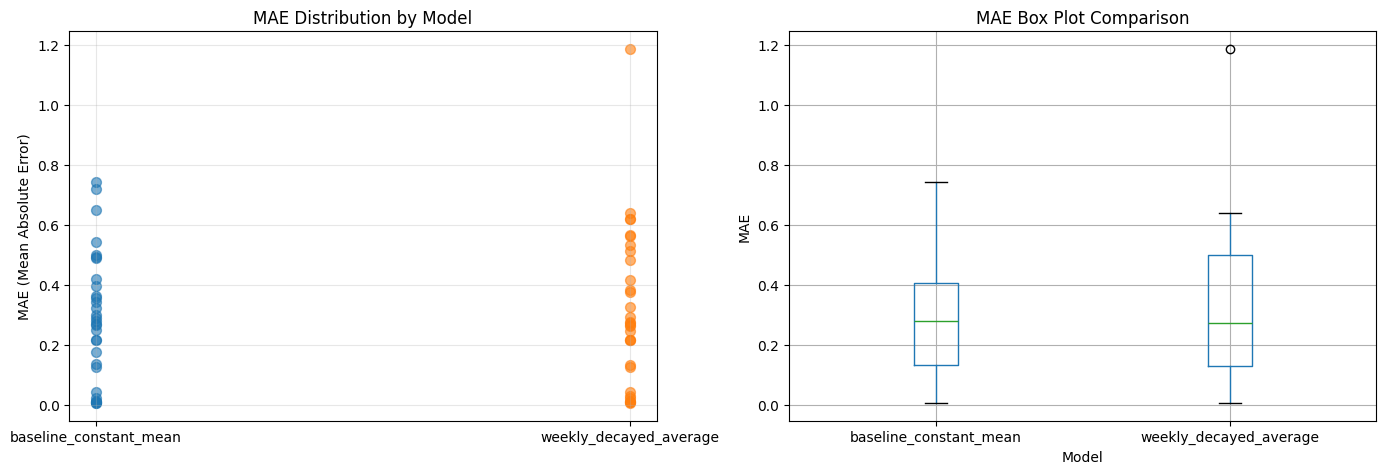


BEST MODEL PER MERCHANT (by MAE)

model_name
baseline_constant_mean    18
weekly_decayed_average    13
Name: count, dtype: int64

Total merchants: 31


In [108]:
# ============================================================================
# POST-EVALUATION ANALYSIS
# ============================================================================

# Summary statistics by model
print(f'\n{"="*80}')
print('MODEL PERFORMANCE STATISTICS')
print(f'{"="*80}\n')

for model_name in sorted(comparison_df['model_name'].unique()):
    model_subset = comparison_df[comparison_df['model_name'] == model_name]
    print(f'{model_name}:')
    print(f'  Merchants evaluated: {len(model_subset)}')
    print(f'  MAE - Mean: {model_subset["mae"].mean():.6f}, Median: {model_subset["mae"].median():.6f}, Std: {model_subset["mae"].std():.6f}')
    print(f'  MAPE - Mean: {model_subset["mape"].mean():.2f}%, Median: {model_subset["mape"].median():.2f}%')
    print()

# Show scatter of MAE values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: MAE by model
for model_name in sorted(comparison_df['model_name'].unique()):
    model_subset = comparison_df[comparison_df['model_name'] == model_name]
    axes[0].scatter(
        [model_name] * len(model_subset),
        model_subset['mae'],
        alpha=0.6,
        s=50,
        label=model_name
    )

axes[0].set_ylabel('MAE (Mean Absolute Error)')
axes[0].set_title('MAE Distribution by Model')
axes[0].grid(alpha=0.3)

# Box plot: MAE comparison
comparison_df.boxplot(column='mae', by='model_name', ax=axes[1])
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Model')
axes[1].set_title('MAE Box Plot Comparison')
plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

# Summary: which model won for each merchant
print(f'\n{"="*80}')
print('BEST MODEL PER MERCHANT (by MAE)')
print(f'{"="*80}\n')

best_by_merchant = comparison_df.loc[comparison_df.groupby('merchant_id')['mae'].idxmin()]
model_wins = best_by_merchant['model_name'].value_counts()
print(model_wins)
print(f'\nTotal merchants: {len(best_by_merchant)}')


MERCHANT PREDICTION VISUALIZATION (Rolling Window Example)

Using cached model predictions from evaluation step...


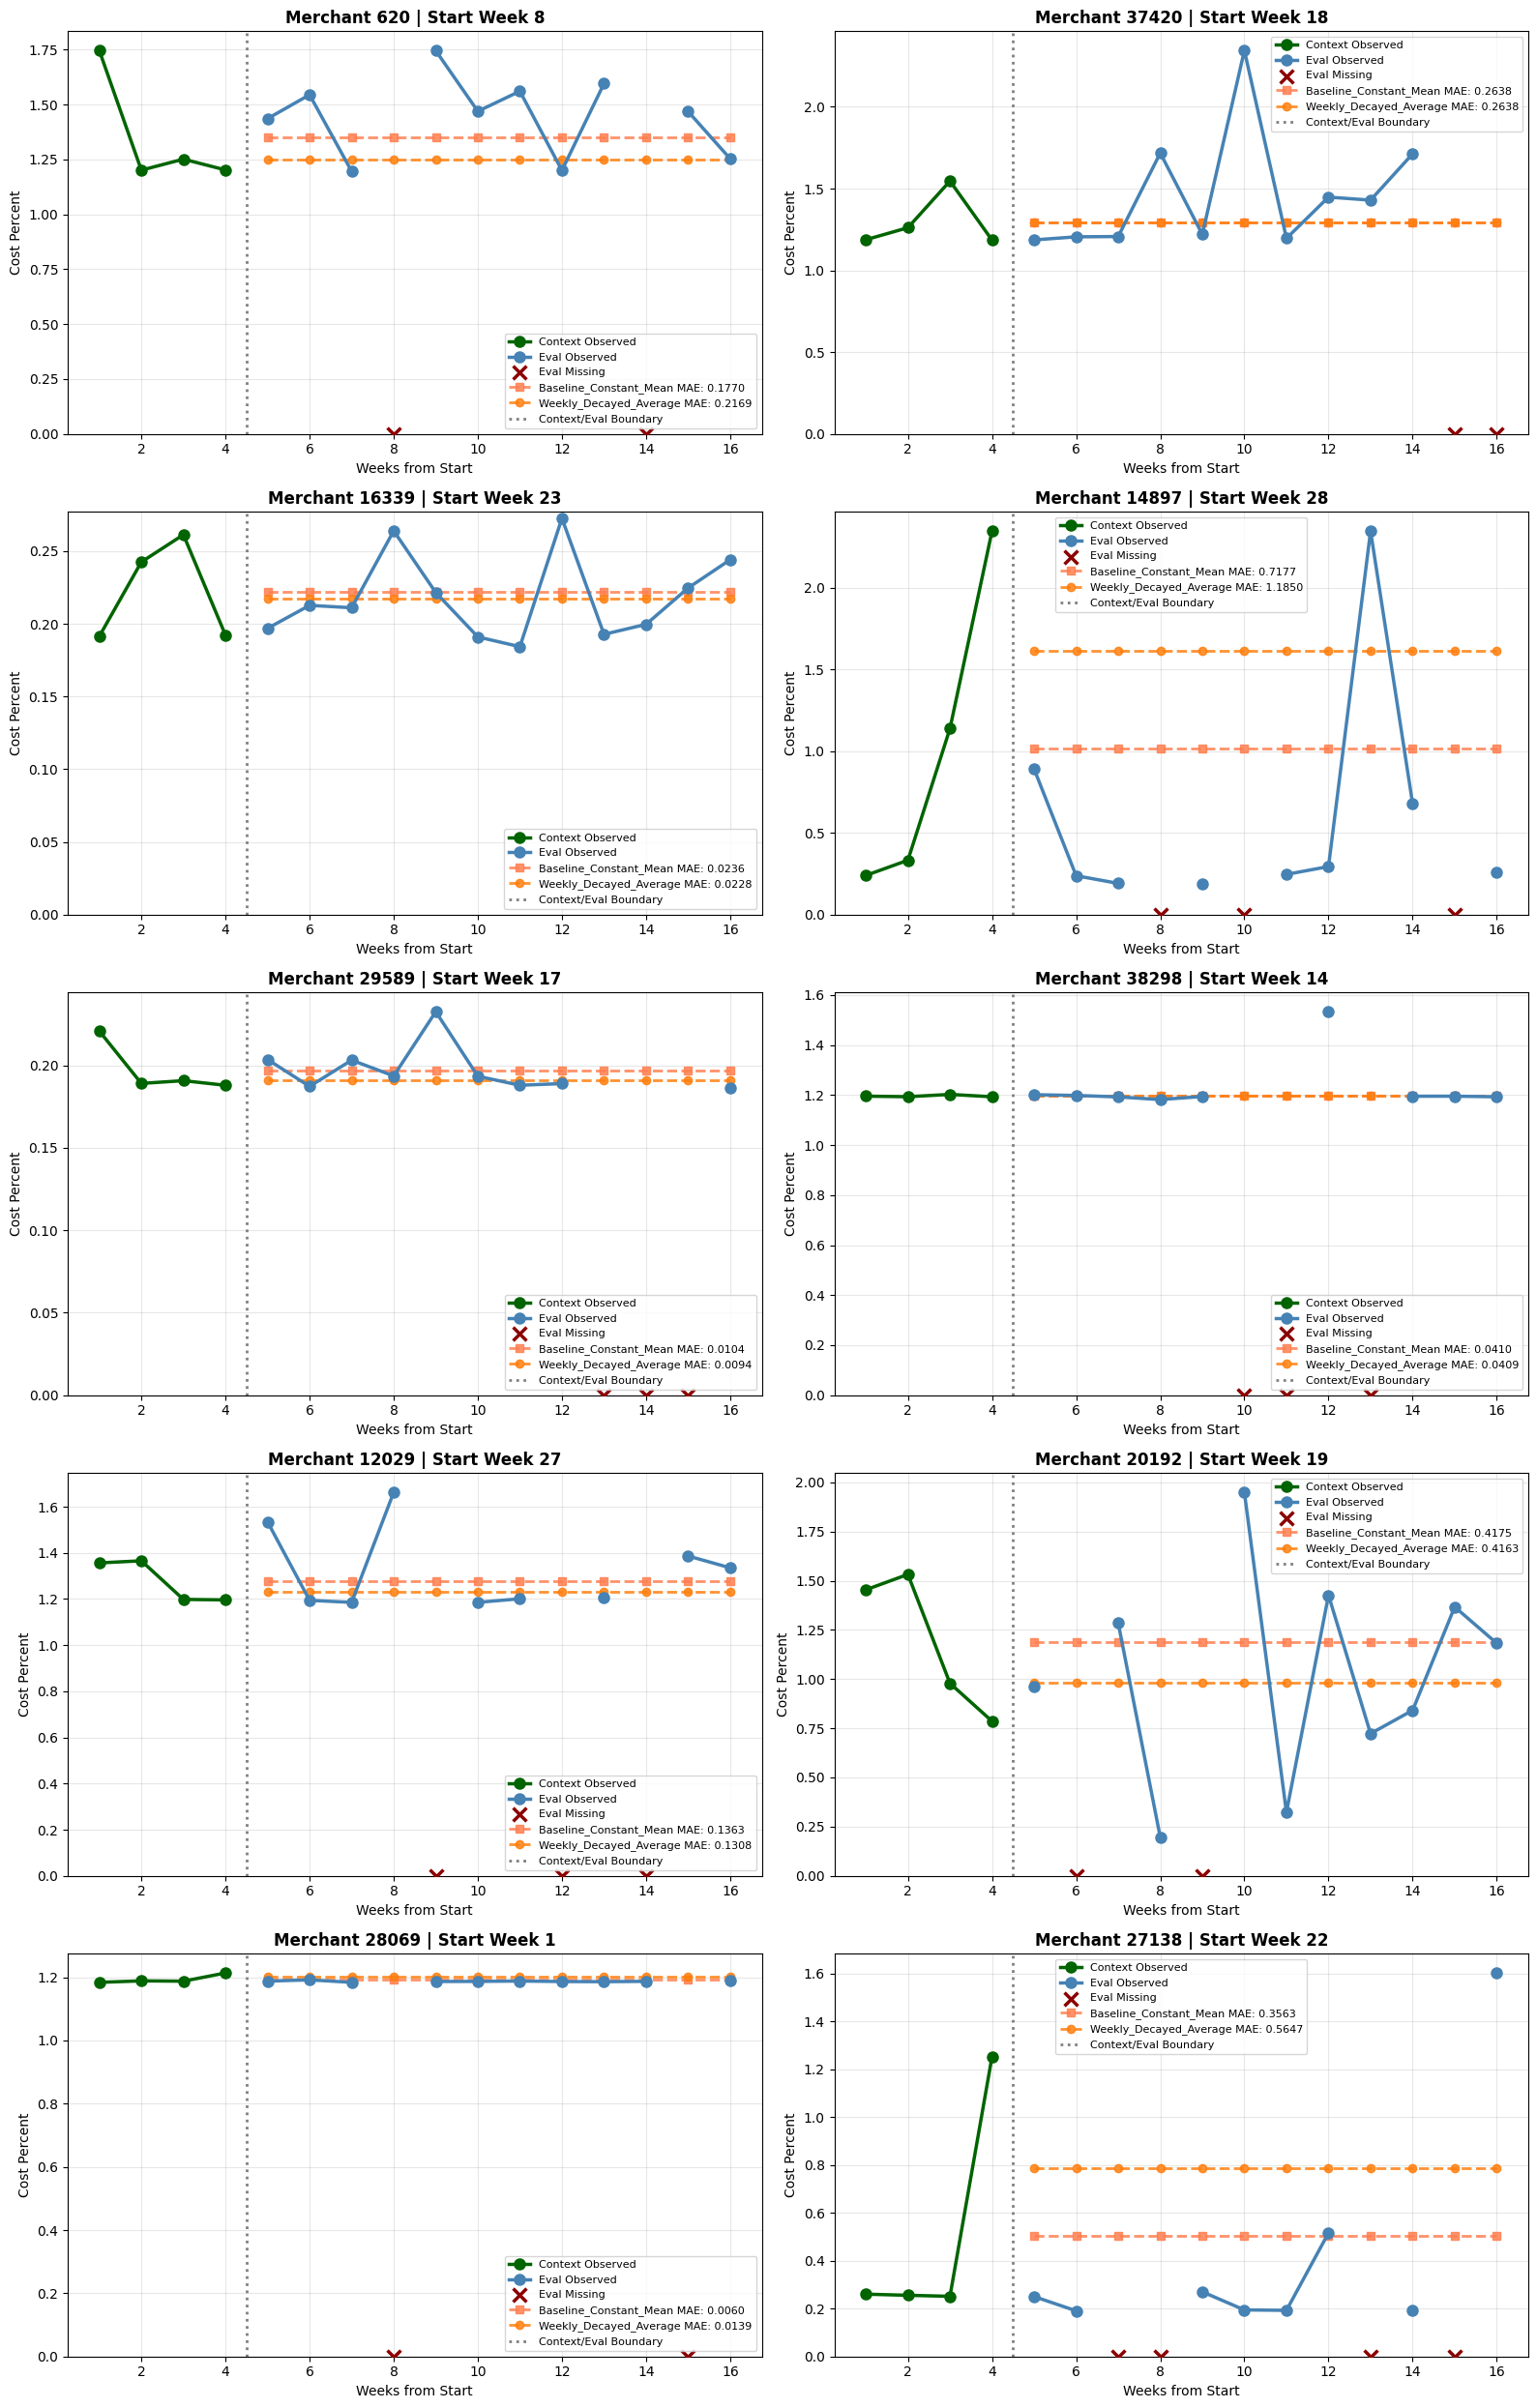

✓ Visualization complete: displayed 10 scenarios


In [109]:
# ============================================================================
# VISUALIZATION: Sample Merchants with Model Predictions (Rolling Window Support)
# ============================================================================

print(f'\n{"="*80}')
print('MERCHANT PREDICTION VISUALIZATION (Rolling Window Example)')
print(f'{"="*80}\n')

# Prepare visualization data by collecting actual values and predictions
visualization_data = []

# Check if we have pre-computed predictions
use_cached_predictions = 'GLOBAL_MODEL_PREDICTIONS' in locals() and GLOBAL_MODEL_PREDICTIONS

if not use_cached_predictions:
    print("⚠ No cached predictions found in GLOBAL_MODEL_PREDICTIONS. Models would need to be re-run.")
    # Exit early or handle gracefully
    sample_merchants = []
else:
    print("Using cached model predictions from evaluation step...")
    # Get list of models
    available_models = sorted(MODEL_REGISTRY.keys())
    first_model = available_models[0]
    
    # Identify unique merchants present in the predictions
    # Keys in predictions are (merchant_id, start_week)
    all_keys = list(GLOBAL_MODEL_PREDICTIONS[first_model].keys())
    present_merchants = list(set([k[0] for k in all_keys]))
    
    # Randomly Sample merchants
    np.random.seed(42)
    sample_merchants = np.random.choice(present_merchants, size=min(10, len(present_merchants)), replace=False)

for merchant_id in sample_merchants:
    try:
        # 1. Select a valid start week for visualization (random or first available)
        # We look at the first model's predictions to find valid start weeks
        valid_keys = [k for k in GLOBAL_MODEL_PREDICTIONS[first_model].keys() if k[0] == merchant_id]
        if not valid_keys:
            continue
            
        # Pick one valid start week to visualize
        # We pick one roughly in the middle of available ones to be interesting, or just the first
        selected_key = valid_keys[len(valid_keys)//2] 
        start_week = selected_key[1]
        
        # 2. Define Window for this Start Week
        local_context_weeks = []
        for w_idx in range(WINDOW_CONTEXT_LEN):
            abs_week = start_week + w_idx
            local_context_weeks.append((abs_week - 1) % 52 + 1)
            
        local_eval_weeks = []
        for w_idx in range(WINDOW_CONTEXT_LEN, WINDOW_TOTAL_LEN):
            abs_week = start_week + w_idx
            local_eval_weeks.append((abs_week - 1) % 52 + 1)
            
        # 3. Retrieve Actual Data specific to this window
        # We need to fetch (year, week) tuples again to get exact values including year wraparound
        
        # Fetch merchant data for query year and next year
        merchant_data = working_weekly_df[
            (working_weekly_df['merchant_id'] == merchant_id) &
            (working_weekly_df['split_year'].isin([test_year, test_year + 1]))
        ].copy()
        merchant_data_indexed = merchant_data.set_index(['split_year', 'week_of_year'])
        
        context_actuals = []
        context_weeks_plot = []
        context_dropout_plot = []
        
        for w_idx, wk_num in enumerate(local_context_weeks):
            abs_week = start_week + w_idx
            y_off = (abs_week - 1) // 52
            eff_year = test_year + y_off
            
            val = merchant_data_indexed.reindex([(eff_year, wk_num)])['cost_percent'].values
            
            # For plotting, we use linear x-axis (0..WindowLen) or absolute week?
            # Using actual week number is confusing if it wraps (52 -> 1). 
            # Better to plot as "Weeks from Start" or simple index, OR label x-axis intelligently.
            # Let's use continuous week index for x-axis to avoid wrap-around visualization artifacts.
            plot_idx = w_idx + 1 # 1-based index in window
            
            if len(val) > 0 and pd.notna(val[0]):
                context_actuals.append(float(val[0]))
                context_weeks_plot.append(plot_idx) 
            else:
                context_dropout_plot.append(plot_idx)

        eval_actuals = [] # Points to connect line
        eval_actuals_raw = [] # All points including NaNs
        eval_weeks_plot = [] # For x-axis
        
        for w_idx, wk_num in enumerate(local_eval_weeks):
            abs_week = start_week + WINDOW_CONTEXT_LEN + w_idx
            y_off = (abs_week - 1) // 52
            eff_year = test_year + y_off
            
            val = merchant_data_indexed.reindex([(eff_year, wk_num)])['cost_percent'].values
            val_float = float(val[0]) if len(val) > 0 and pd.notna(val[0]) else np.nan
            
            eval_actuals_raw.append(val_float)
            
            plot_idx = WINDOW_CONTEXT_LEN + w_idx + 1
            eval_weeks_plot.append(plot_idx)
            
            if pd.notna(val_float):
                eval_actuals.append(val_float)

        # 4. Get Predictions
        model_predictions = {}
        model_mae_scores = {}
        
        for model_name in available_models:
            if model_name not in GLOBAL_MODEL_PREDICTIONS:
                continue
            
            preds_dict = GLOBAL_MODEL_PREDICTIONS[model_name]
            key = (merchant_id, start_week)
            
            if key in preds_dict:
                model_predictions[model_name] = preds_dict[key]
                
                # Retrieve MAE specific to this window?
                # We didn't save per-window MAE in GLOBAL_MODEL_PREDICTIONS, only predictions.
                # We can recompute or just lookup in stats if we saved them... 
                # comparison_df has detailed results.
                
                # Check if comparison_df exists and has this row
                if 'comparison_df' in locals():
                    row = comparison_df[
                        (comparison_df['merchant_id'] == merchant_id) & 
                        (comparison_df['model_name'] == model_name) &
                        (comparison_df['start_week'] == start_week)
                    ]
                    if not row.empty:
                        model_mae_scores[model_name] = row['mae'].values[0]
                    else:
                        model_mae_scores[model_name] = np.nan
                else:
                    model_mae_scores[model_name] = np.nan
            else:
                # Should not happen if models were run consistently
                continue

        visualization_data.append({
            'merchant_id': merchant_id,
            'start_week': start_week,
            'context_actuals': np.array(context_actuals),
            'context_weeks_plot': context_weeks_plot,
            'context_dropout_plot': context_dropout_plot,
            'eval_actuals_raw': np.array(eval_actuals_raw),
            'eval_weeks_plot': eval_weeks_plot,
            'model_predictions': model_predictions,
            'model_mae_scores': model_mae_scores,
            'context_week_labels': local_context_weeks, # Real week numbers for X-axis labels if needed
            'eval_week_labels': local_eval_weeks
        })
        
    except Exception as e:
        print(f"Error preparing visualization for merchant {merchant_id}: {e}")
        continue

# Create visualizations
if visualization_data:
    n_merchants = len(visualization_data)
    n_cols = 2
    n_rows = (n_merchants + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_merchants > 1 else [axes]
    
    for idx, (ax, vis_data) in enumerate(zip(axes[:n_merchants], visualization_data)):
        merchant_id = vis_data['merchant_id']
        start_week = vis_data['start_week']
        
        # Plot Context
        if len(vis_data['context_actuals']) > 0:
            ax.plot(
                vis_data['context_weeks_plot'],
                vis_data['context_actuals'],
                'o-', linewidth=2.5, markersize=8, color='darkgreen',
                label='Context Observed', zorder=3
            )
            
        if vis_data['context_dropout_plot']:
             ax.scatter(
                vis_data['context_dropout_plot'],
                np.zeros(len(vis_data['context_dropout_plot'])),
                marker='x', s=100, color='red', linewidths=2.5,
                label='Context Missing', zorder=3
            )

        # Plot Eval
        eval_weeks = vis_data['eval_weeks_plot']
        eval_vals = vis_data['eval_actuals_raw']
        eval_real_mask = np.isfinite(eval_vals)
        
        # Plot continuous line for observed parts? Or Just points? 
        # Standard plot handles NaNs by breaking line.
        ax.plot(
            eval_weeks,
            eval_vals,
            'o-', linewidth=2.5, markersize=8, color='steelblue',
            label='Eval Observed', zorder=3
        )
        
        # Missing Eval
        missing_indices = np.where(~eval_real_mask)[0]
        if len(missing_indices) > 0:
            missing_weeks = [eval_weeks[i] for i in missing_indices]
            ax.scatter(
                missing_weeks,
                np.zeros(len(missing_weeks)),
                marker='x', s=100, color='darkred', linewidths=2.5,
                label='Eval Missing', zorder=3
            )

        # Plot Predictions
        model_colors = {
            'baseline_constant_mean': ('coral', 's'),
            'weekwise_linear_regression': ('purple', '^'),
            'weekwise_ridge_regression': ('darkgreen', 'D'),
        }
        
        for model_name, pred in vis_data['model_predictions'].items():
            mae = vis_data['model_mae_scores'].get(model_name, np.nan)
            
            if model_name in model_colors:
                color, marker = model_colors[model_name]
            else:
                color = f'C{list(vis_data["model_predictions"].keys()).index(model_name)}'
                marker = 'o'
            
            model_label = model_name.replace('weekwise_', 'WW-').replace('_regression', '').title()
            
            ax.plot(
                eval_weeks,
                pred,
                f'{marker}--', linewidth=2, markersize=6, color=color, alpha=0.85,
                label=f'{model_label} MAE: {mae:.4f}', zorder=2
            )

        # Boundary Line
        boundary = (max(vis_data['context_weeks_plot']) + min(vis_data['eval_weeks_plot'])) / 2.0
        ax.axvline(x=boundary, color='gray', linestyle=':', linewidth=2, label='Context/Eval Boundary')
        
        # Formatting
        ax.set_title(f'Merchant {merchant_id} | Start Week {start_week}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Weeks from Start', fontsize=10)
        ax.set_ylabel('Cost Percent', fontsize=10)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, ax.get_ylim()[1])  # Adjust as needed based on data range
        
    # Hide unused axes
    for idx in range(n_merchants, len(axes)):
        axes[idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    print(f'✓ Visualization complete: displayed {n_merchants} scenarios')

In [110]:
# # Dropout distribution analysis for rolling onboarding windows with year crossover
# WINDOW_CONTEXT_LEN = 4
# WINDOW_EVAL_LEN = 12
# WINDOW_TOTAL_LEN = WINDOW_CONTEXT_LEN + WINDOW_EVAL_LEN
# WINDOW_START_WEEKS = list(range(1, 53))  # 1..52, can cross into next year

# # IMPORTANT: No synthetic history is used here.
# # We only count observed (non-null) rows in the raw weekly panel per merchant-year-start window.
# dropout_rows = []
# for (mid, yr), _ in working_weekly_df.groupby(['merchant_id', 'split_year']):
#     subset = working_weekly_df[
#         (working_weekly_df['merchant_id'] == mid)
#         & (working_weekly_df['split_year'].isin([yr, yr + 1]))
#     ][['split_year', 'week_of_year', 'cost_percent']].copy()

#     subset['abs_week'] = np.where(subset['split_year'] == yr, subset['week_of_year'], subset['week_of_year'] + 52)
#     week_to_val = subset.set_index('abs_week')['cost_percent'].to_dict()

#     for start_week in WINDOW_START_WEEKS:
#         context_weeks = list(range(start_week, start_week + WINDOW_CONTEXT_LEN))
#         eval_weeks = list(range(start_week + WINDOW_CONTEXT_LEN, start_week + WINDOW_TOTAL_LEN))

#         context_vals = np.array([week_to_val.get(wk, np.nan) for wk in context_weeks], dtype=float)
#         eval_vals = np.array([week_to_val.get(wk, np.nan) for wk in eval_weeks], dtype=float)

#         context_obs = int(np.isfinite(context_vals).sum())
#         eval_obs = int(np.isfinite(eval_vals).sum())

#         context_total = len(context_weeks)
#         eval_total = len(eval_weeks)
#         total_obs = context_obs + eval_obs
#         total_window = context_total + eval_total

#         dropout_rows.append({
#             'merchant_id': int(mid),
#             'split_year': int(yr),
#             'window_start': int(start_week),
#             'window_end': int(start_week + WINDOW_TOTAL_LEN - 1),
#             'context_obs': context_obs,
#             'context_dropout_rows': context_total - context_obs,
#             'context_dropout_prob': 1.0 - (context_obs / context_total),
#             'eval_obs': eval_obs,
#             'eval_dropout_rows': eval_total - eval_obs,
#             'eval_dropout_prob': 1.0 - (eval_obs / eval_total),
#             'window_obs': total_obs,
#             'window_dropout_rows': total_window - total_obs,
#             'window_dropout_prob': 1.0 - (total_obs / total_window),
#         })

# dropout_df = pd.DataFrame(dropout_rows).sort_values(['merchant_id', 'split_year', 'window_start']).reset_index(drop=True)

# print('Dropout probability analysis (rolling windows with year crossover, no synthetic history)')
# print(f'  Merchant-year-start windows: {len(dropout_df):,}')
# print(f'  Context length: {WINDOW_CONTEXT_LEN} weeks')
# print(f'  Eval length: {WINDOW_EVAL_LEN} weeks')
# print(f'  Start weeks per year: {len(WINDOW_START_WEEKS)} (1-52)')

# print('\nOverall means:')
# print(f"  Mean context dropout probability: {dropout_df['context_dropout_prob'].mean():.3f}")
# print(f"  Mean eval dropout probability:    {dropout_df['eval_dropout_prob'].mean():.3f}")
# print(f"  Mean full-window dropout prob:    {dropout_df['window_dropout_prob'].mean():.3f}")

# print('\nDropout probability quantiles:')
# quantiles = dropout_df[['context_dropout_prob', 'eval_dropout_prob', 'window_dropout_prob']].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 1.0]).round(3)
# display(quantiles)

# # Distribution plots
# fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# axes[0].hist(dropout_df['context_dropout_prob'], bins=np.linspace(0, 1, 11), color='darkgreen', alpha=0.75, edgecolor='black')
# axes[0].set_title('Context Dropout Probability\n(rolling 4-week context)')
# axes[0].set_xlabel('P(dropout row)')
# axes[0].set_ylabel('Window count')
# axes[0].grid(axis='y', alpha=0.3)

# axes[1].hist(dropout_df['eval_dropout_prob'], bins=np.linspace(0, 1, 13), color='steelblue', alpha=0.75, edgecolor='black')
# axes[1].set_title('Evaluation Dropout Probability\n(rolling 12-week eval)')
# axes[1].set_xlabel('P(dropout row)')
# axes[1].grid(axis='y', alpha=0.3)

# axes[2].hist(dropout_df['window_dropout_prob'], bins=np.linspace(0, 1, 17), color='coral', alpha=0.75, edgecolor='black')
# axes[2].set_title('Full Rolling 16-Week Window Dropout Probability')
# axes[2].set_xlabel('P(dropout row)')
# axes[2].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Merchant-level distribution: average across all years and rolling starts
# merchant_dropout = (
#     dropout_df
#     .groupby('merchant_id', as_index=False)
#     .agg(
#         n_windows=('window_start', 'count'),
#         context_dropout_prob_mean=('context_dropout_prob', 'mean'),
#         eval_dropout_prob_mean=('eval_dropout_prob', 'mean'),
#         window_dropout_prob_mean=('window_dropout_prob', 'mean'),
#     )
#     .sort_values('window_dropout_prob_mean', ascending=False)
#     .reset_index(drop=True)
# )

# print('\nMerchant-level average dropout (across years and rolling starts):')
# display(merchant_dropout.head(15).round(3))

# # Save a compact table for downstream filtering if needed
# dropout_summary = dropout_df.copy()
# print("\nSaved DataFrame: dropout_summary")

In [111]:
# # Conditional dropout view: all rolling windows vs conducted rolling windows only
# conducted_mask = (dropout_summary['context_obs'] >= MIN_REAL_CONTEXT_POINTS) & (dropout_summary['eval_obs'] >= MIN_REAL_EVAL_POINTS)
# conducted_dropout = dropout_summary[conducted_mask].copy()

# print('Conducted-window filter (rolling windows, no synthetic history):')
# print(f'  Rules: context_obs >= {MIN_REAL_CONTEXT_POINTS}, eval_obs >= {MIN_REAL_EVAL_POINTS}')
# print(f'  All rolling windows: {len(dropout_summary):,}')
# print(f'  Conducted rolling windows: {len(conducted_dropout):,} ({len(conducted_dropout)/max(len(dropout_summary),1):.1%})')

# comparison = pd.DataFrame({
#     'population': ['all_rolling_windows', 'conducted_rolling_windows'],
#     'n': [len(dropout_summary), len(conducted_dropout)],
#     'context_dropout_mean': [dropout_summary['context_dropout_prob'].mean(), conducted_dropout['context_dropout_prob'].mean()],
#     'eval_dropout_mean': [dropout_summary['eval_dropout_prob'].mean(), conducted_dropout['eval_dropout_prob'].mean()],
#     'window_dropout_mean': [dropout_summary['window_dropout_prob'].mean(), conducted_dropout['window_dropout_prob'].mean()],
# }).round(3)
# display(comparison)

# if len(conducted_dropout) > 0:
#     fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

#     bins_ctx = np.linspace(0, 1, 11)
#     bins_eval = np.linspace(0, 1, 13)
#     bins_win = np.linspace(0, 1, 17)

#     axes[0].hist(dropout_summary['context_dropout_prob'], bins=bins_ctx, alpha=0.35, label='All rolling windows', color='gray', edgecolor='black')
#     axes[0].hist(conducted_dropout['context_dropout_prob'], bins=bins_ctx, alpha=0.75, label='Conducted rolling windows', color='darkgreen', edgecolor='black')
#     axes[0].set_title('Context Dropout Probability')
#     axes[0].set_xlabel('P(dropout row)')
#     axes[0].set_ylabel('Window count')
#     axes[0].grid(axis='y', alpha=0.3)
#     axes[0].legend()

#     axes[1].hist(dropout_summary['eval_dropout_prob'], bins=bins_eval, alpha=0.35, label='All rolling windows', color='gray', edgecolor='black')
#     axes[1].hist(conducted_dropout['eval_dropout_prob'], bins=bins_eval, alpha=0.75, label='Conducted rolling windows', color='steelblue', edgecolor='black')
#     axes[1].set_title('Evaluation Dropout Probability')
#     axes[1].set_xlabel('P(dropout row)')
#     axes[1].grid(axis='y', alpha=0.3)
#     axes[1].legend()

#     axes[2].hist(dropout_summary['window_dropout_prob'], bins=bins_win, alpha=0.35, label='All rolling windows', color='gray', edgecolor='black')
#     axes[2].hist(conducted_dropout['window_dropout_prob'], bins=bins_win, alpha=0.75, label='Conducted rolling windows', color='coral', edgecolor='black')
#     axes[2].set_title('Full 16-Week Dropout Probability')
#     axes[2].set_xlabel('P(dropout row)')
#     axes[2].grid(axis='y', alpha=0.3)
#     axes[2].legend()

#     plt.tight_layout()
#     plt.show()

#     print('\nConducted rolling-window quantiles:')
#     display(
#         conducted_dropout[['context_dropout_prob', 'eval_dropout_prob', 'window_dropout_prob']]
#         .quantile([0.0, 0.25, 0.5, 0.75, 0.9, 1.0])
#         .round(3)
#     )
# else:
#     print('No rolling windows satisfy conducted criteria.')